<a href="https://colab.research.google.com/github/Forla03/BOSTARTER/blob/main/assignment_module_one.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Team members**

| Student ID | Name | Email |
|---|---|---|
| 0000000000 | Name Surname | name.surname@studio.unibo.it |
| 0000000000 | Name Surname | name.surname@studio.unibo.it |

# Coin Detection, Classification and Counting

**Image Processing and Computer Vision — Assignment Module 1**

Given a photograph, the pipeline must detect every coin, identify its denomination and sum the amount, using only traditional computer-vision techniques. Our approach has four stages:

1. **Detection** — circular Hough transform on a smoothed grayscale image, followed by a validation step that rejects background circles using edge support, contrast and gradient direction, and a second, more permissive Hough pass for coins with weak boundaries.
2. **Material** — colour features of the coin regions separate copper coins (1c, 2c, 5c), gold coins (10c, 20c, 50c) and the two bimetallic coins (1 €, 2 €). Initial thresholds are calibrated on the eight reference images; the copper/gold split is then adapted to unlabelled target features with Otsu.
3. **Denomination** — within a material group, the denomination is decided by the physical diameter published by the ECB. The pixels-per-millimetre scale of each image is estimated from the coins it contains.
4. **Output** — the required per-image listing and the total amount.

**Experimental protocol.** The eight labelled references calibrate the initial material rules. Unlabelled target features supply the Otsu threshold and batch scale. The target annotations linked in Section 5 were consulted during development: count deficits guided the recovery investigation, and annotated metrics informed variant selection, including Otsu. The initial colour regions and bimetal fallback also used a small annotated subset whose membership and size were not retained. These results are therefore **descriptive evaluation on development-exposed data**, not an independent test of generalisation. No retrospective split is claimed.

Inference does not read target annotations or apply manual per-image corrections. Otsu computes its threshold without labels; the decision to use it was label-informed. Favouring denomination-multiset F1 was an exploratory project choice, not a criterion fixed before examining results or mandated by the assignment. The assignment requires traditional CV, justified decisions, and instance/amount correctness; it does not specify an independent-test protocol. Metric definitions and annotation limitations are stated once in Section 5.

## 0. Setup

Provide `coin_dataset.zip` (or an already extracted `coin_dataset/` folder) in the working directory, or adjust `DRIVE_ZIP_PATH` on Colab. Dependencies: OpenCV, NumPy, Matplotlib; the self-evaluation additionally needs pandas, openpyxl and Jinja2 (for styled tables).

In [ ]:
import copy
import glob
import os
import platform
import shutil
import zipfile
from collections import Counter
from importlib.metadata import PackageNotFoundError, version

import cv2
import matplotlib.pyplot as plt
import numpy as np

ZIP_PATH = "./coin_dataset.zip"
DRIVE_ZIP_PATH = "/content/drive/MyDrive/AssignmentsIPCV/coin_dataset.zip"
DATASET_DIR = "./coin_dataset"

# An extracted dataset is sufficient; the ZIP is needed only if a folder is missing.
dataset_ready = all(
    os.path.isdir(os.path.join(DATASET_DIR, folder))
    for folder in ("reference_set", "target_set")
)
if not dataset_ready:
    if not os.path.exists(ZIP_PATH):
        try:
            from google.colab import drive
            drive.mount("/content/drive")
            if os.path.exists(DRIVE_ZIP_PATH):
                shutil.copy2(DRIVE_ZIP_PATH, ZIP_PATH)
        except ImportError:
            pass
    if not os.path.exists(ZIP_PATH):
        raise FileNotFoundError(
            "Provide coin_dataset.zip or an extracted coin_dataset directory, or update DRIVE_ZIP_PATH."
        )
    with zipfile.ZipFile(ZIP_PATH, "r") as archive:
        archive.extractall(".")

REFERENCE_DIR = os.path.join(DATASET_DIR, "reference_set")
TARGET_DIR = os.path.join(DATASET_DIR, "target_set")

print(f"Python {platform.python_version()} | OpenCV {cv2.__version__} | NumPy {np.__version__}")
for package in ("matplotlib", "pandas", "openpyxl"):
    try:
        print(f"{package}: {version(package)}")
    except PackageNotFoundError:
        print(f"{package}: not installed (only needed for the self-evaluation)")

Python 3.12.14 | OpenCV 4.12.0 | NumPy 2.3.5
matplotlib: 3.10.8
pandas: 2.2.3
openpyxl: 3.1.5


In [ ]:
def image_number(path):
    """image_17.jpg -> 17, used to sort the target images in their natural order."""
    return int(os.path.splitext(os.path.basename(path))[0].split("_")[1])


def load_image(path):
    image = cv2.imread(path)
    if image is None:
        raise FileNotFoundError(f"Unable to load image: {path}")
    return image


def show(images, titles, ncols=None, figsize=4.5, bgr=True):
    """Display a row (or grid) of images with titles."""
    ncols = ncols or len(images)
    nrows = int(np.ceil(len(images) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize * ncols, figsize * nrows), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, image, title in zip(axes.ravel(), images, titles):
        if image.ndim == 2:
            ax.imshow(image, cmap="gray")
        else:
            ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB) if bgr else image)
        ax.set_title(title, fontsize=10)
    plt.tight_layout()
    plt.show()


target_paths = sorted(glob.glob(os.path.join(TARGET_DIR, "*.jpg")), key=image_number)
reference_paths = sorted(glob.glob(os.path.join(REFERENCE_DIR, "*.jpg")))
print(f"{len(reference_paths)} reference images, {len(target_paths)} target images")

8 reference images, 142 target images


## 1. A look at the data

Two properties of the dataset drive several decisions below.

**The target images have the red and blue channels swapped.** As loaded, copper coins look blue and the whole target set has a cold cast, while the reference images have normal colours. Swapping the channels back restores natural colours (figure below). All colour features are therefore computed on the corrected image. Detection, instead, works on the grayscale of the image *as stored*: we verified that computing the grayscale after the correction changes the coin count in 12 of the 142 images, mostly losing coins, because the stored channel order gives more weight to the (true) red channel, where copper coins contrast best against the backgrounds of this dataset.

**The reference coins were photographed at different distances**, so their pixel size cannot be used directly as a size prototype (Section 3.4 measures this: 6.2 to 8.4 px/mm across the eight images). The references are used for colour only.

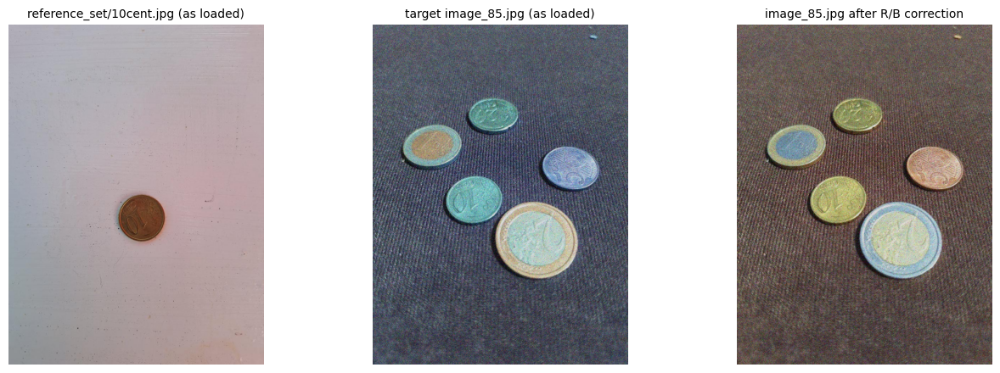

In [ ]:
def correct_target_colour(image_bgr):
    """Undo the R/B channel swap of the target set. The result is again a BGR image."""
    return image_bgr[:, :, ::-1].copy()


example_raw = load_image(os.path.join(TARGET_DIR, "image_85.jpg"))
show(
    [load_image(reference_paths[0]), example_raw, correct_target_colour(example_raw)],
    ["reference_set/10cent.jpg (as loaded)", "target image_85.jpg (as loaded)", "image_85.jpg after R/B correction"],
)

## 2. Coin detection

### 2.1 Pre-processing

Grayscale → Gaussian smoothing (9×9, σ = 2) → Canny (50/120). Smoothing suppresses the engraving and the background texture while staying small compared with the minimum coin diameter (~70 px). The Canny map is used by the validation step; the Hough transform below runs its own internal Canny on the smoothed image.

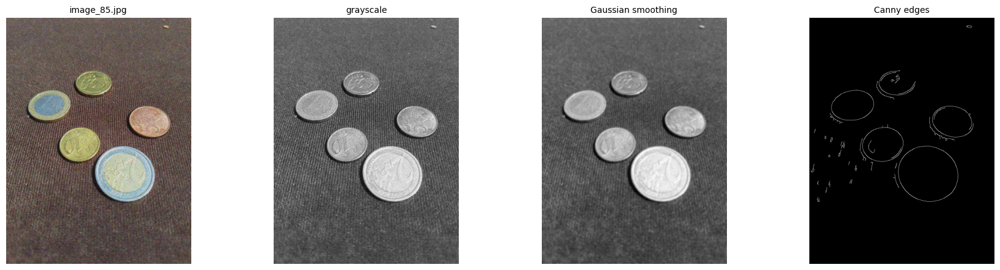

In [ ]:
def preprocess_image(image, gaussian_kernel=(9, 9), sigma=2, canny_low=50, canny_high=120):
    """Return (gray, blurred, edges) for a BGR image."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, gaussian_kernel, sigmaX=sigma)
    edges = cv2.Canny(blurred, threshold1=canny_low, threshold2=canny_high)
    return gray, blurred, edges


gray, blurred, edges = preprocess_image(example_raw)
show([correct_target_colour(example_raw), gray, blurred, edges],
     ["image_85.jpg", "grayscale", "Gaussian smoothing", "Canny edges"])

### 2.2 Circular Hough transform

`cv2.HoughCircles` with the gradient method: accumulator resolution `dp = 1.2`, minimum distance between centres 70 px (smaller than the smallest coin diameter, so touching coins are still separated), `param1 = 120` (upper Canny threshold of the internal edge detector), `param2 = 25` (accumulator threshold) and radii between 35 and 110 px. The radius range covers the coin sizes observed in the dataset; we tested `maxRadius = 140` and it only added large background circles (e.g. in images 27 and 85). A lower `param2` finds more coins but also more background circles: this is why we keep a moderate value here and add a validated second pass later (Section 2.4).

5 candidate(s):
[[447 602 101]
 [287 512  84]
 [164 296 103]
 [551 424  83]
 [333 224  76]]


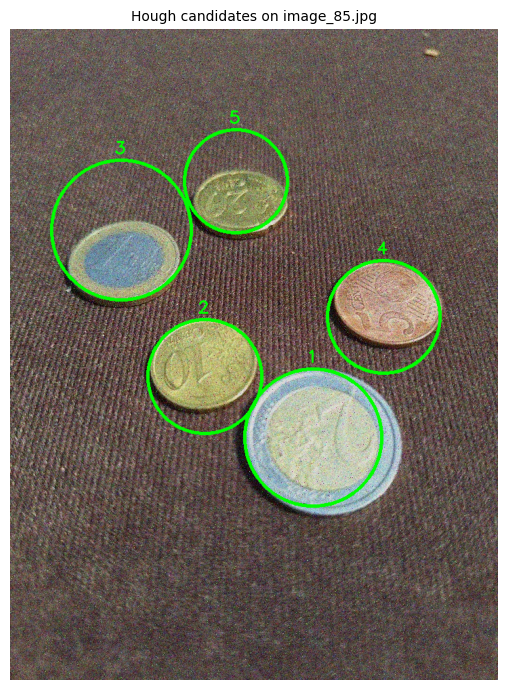

In [ ]:
def detect_coin_candidates(blurred, dp=1.2, min_dist=70, param1=120, param2=25, min_radius=35, max_radius=110):
    """Hough circle proposals as an (N, 3) integer array of (x, y, r)."""
    circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=dp, minDist=min_dist, param1=param1, param2=param2,
        minRadius=min_radius, maxRadius=max_radius,
    )
    if circles is None:
        return np.empty((0, 3), dtype=int)
    return np.round(circles[0]).astype(int)


def draw_circles(image, circles, colours=None, thickness=3):
    """Draw numbered circles; colours is an optional per-circle list of BGR tuples."""
    output = image.copy()
    for i, (x, y, r) in enumerate(circles, start=1):
        colour = (0, 255, 0) if colours is None else colours[i - 1]
        cv2.circle(output, (int(x), int(y)), int(r), colour, thickness)
        cv2.putText(output, str(i), (int(x) - 10, int(y) - int(r) - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, colour, 2)
    return output


circles = detect_coin_candidates(blurred)
print(f"{len(circles)} candidate(s):\n{circles}")
show([draw_circles(correct_target_colour(example_raw), circles)], ["Hough candidates on image_85.jpg"], figsize=7)

### 2.3 Candidate validation

Background structures (tiles, textures, shadows) can also collect Hough votes. Every proposal is therefore checked against three complementary pieces of evidence from the proposed boundary and its surrounding regions:

* **Edge support** `E` — fraction of 360 angular positions where a Canny pixel lies within ±3 px of the circle. A real coin boundary is an almost closed edge curve.
* **Region contrast** `C` — absolute difference between the mean intensity inside `0.8r` and in the annulus `1.05r–1.25r`. The gap around `r` avoids measuring the boundary itself.
* **Radial-gradient alignment** `G` — at each angle, the strongest Sobel gradient within ±4 px of the circle is compared with the radial direction; `G` is the mean absolute cosine over angles whose strongest gradient magnitude is at least 10; it is zero if no angle qualifies. On a coin the intensity gradient at the rim points along the radius, whatever the polarity (bright coin on dark floor or the opposite).

A candidate is accepted when it is fully inside the image and either `G ≥ 0.85` (very clean boundary) or `E ≥ 0.25` and `C ≥ 10` (partial boundary but a region that differs from its surroundings). The OR lets low-contrast coins with a clean rim pass, and coins with broken edges pass if their region stands out. Section 2.6 shows how sensitive the result is to these three thresholds.

In [ ]:
def sample_boundary_evidence(edges, x, y, r, edge_band=3, num_samples=360, grad_x=None, grad_y=None,
                             gradient_magnitude=None, gradient_band=4, min_gradient_magnitude=10.0,
                             cos_values=None, sin_values=None):
    """Edge support E and (if gradient maps are given) radial-gradient alignment G of a circle."""
    height, width = edges.shape
    if cos_values is None or sin_values is None:
        angles = np.linspace(0.0, 2.0 * np.pi, num_samples, endpoint=False)
        cos_values = np.cos(angles).astype(np.float32)
        sin_values = np.sin(angles).astype(np.float32)

    # Edge support: an angle is supported if at least one Canny pixel lies in the radial band.
    offsets = np.arange(-edge_band, edge_band + 1, dtype=np.float32)[:, None]
    edge_x = np.rint(x + (r + offsets) * cos_values[None, :]).astype(np.int32)
    edge_y = np.rint(y + (r + offsets) * sin_values[None, :]).astype(np.int32)
    valid = (edge_x >= 0) & (edge_x < width) & (edge_y >= 0) & (edge_y < height)
    hits = (edges[np.clip(edge_y, 0, height - 1), np.clip(edge_x, 0, width - 1)] > 0) & valid
    edge_support = float(np.mean(np.any(hits, axis=0)))

    if grad_x is None:
        return edge_support, None

    # Gradient alignment: strongest gradient in the band, compared with the radial direction.
    offsets = np.arange(-gradient_band, gradient_band + 1, dtype=np.float32)[:, None]
    gx_pos = np.rint(x + (r + offsets) * cos_values[None, :]).astype(np.int32)
    gy_pos = np.rint(y + (r + offsets) * sin_values[None, :]).astype(np.int32)
    valid = (gx_pos >= 0) & (gx_pos < width) & (gy_pos >= 0) & (gy_pos < height)
    gx_pos = np.clip(gx_pos, 0, width - 1)
    gy_pos = np.clip(gy_pos, 0, height - 1)
    magnitude = np.where(valid, gradient_magnitude[gy_pos, gx_pos], -1.0)
    strongest = np.argmax(magnitude, axis=0)
    columns = np.arange(cos_values.size)
    best_x = gx_pos[strongest, columns]
    best_y = gy_pos[strongest, columns]
    gx = grad_x[best_y, best_x]
    gy = grad_y[best_y, best_x]
    norm = np.sqrt(gx * gx + gy * gy)
    usable = (magnitude[strongest, columns] >= min_gradient_magnitude) & (norm > 1e-6)
    if not np.any(usable):
        return edge_support, 0.0
    alignment = np.abs((gx[usable] * cos_values[usable] + gy[usable] * sin_values[usable]) / norm[usable])
    return edge_support, float(np.mean(alignment))


def compute_region_contrast(gray, x, y, r, inner_scale=0.80, outer_inner_scale=1.05, outer_outer_scale=1.25):
    """|mean(inside 0.8r) - mean(annulus 1.05r..1.25r)|."""
    height, width = gray.shape
    max_radius = int(np.ceil(outer_outer_scale * r))
    x0, x1 = max(0, x - max_radius), min(width, x + max_radius + 1)
    y0, y1 = max(0, y - max_radius), min(height, y + max_radius + 1)
    yy, xx = np.ogrid[y0:y1, x0:x1]
    distance = np.sqrt((xx - x) ** 2 + (yy - y) ** 2)
    inner = gray[y0:y1, x0:x1][distance <= inner_scale * r]
    outer = gray[y0:y1, x0:x1][(distance >= outer_inner_scale * r) & (distance <= outer_outer_scale * r)]
    if inner.size == 0 or outer.size == 0:
        return 0.0
    return abs(float(np.mean(inner)) - float(np.mean(outer)))


def compute_gradient_maps(blurred):
    """Sobel gradients, computed once per image."""
    grad_x = cv2.Sobel(blurred, cv2.CV_32F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(blurred, cv2.CV_32F, 0, 1, ksize=3)
    return grad_x, grad_y, cv2.magnitude(grad_x, grad_y)


def has_sufficient_coin_evidence(edge_support, contrast, gradient_alignment,
                                 min_gradient_alignment=0.85, min_edge_support=0.25, min_contrast=10.0):
    """Acceptance rule: clean rim OR (partial rim AND region contrast)."""
    return gradient_alignment >= min_gradient_alignment or (
        edge_support >= min_edge_support and contrast >= min_contrast
    )


def validate_coin_candidates(gray, blurred, edges, circles, **thresholds):
    """Return (accepted circles as (N, 3) array, per-candidate diagnostics)."""
    height, width = gray.shape
    grad_x, grad_y, magnitude = compute_gradient_maps(blurred)
    accepted, info = [], []
    for x, y, r in circles:
        inside = x - r >= 0 and y - r >= 0 and x + r < width and y + r < height
        edge_support, _ = sample_boundary_evidence(edges, x, y, r)
        contrast = compute_region_contrast(gray, x, y, r)
        _, alignment = sample_boundary_evidence(np.zeros_like(edges), x, y, r, edge_band=0, grad_x=grad_x,
                                                grad_y=grad_y, gradient_magnitude=magnitude)
        valid = inside and has_sufficient_coin_evidence(edge_support, contrast, alignment, **thresholds)
        info.append({"circle": (int(x), int(y), int(r)), "edge_support": edge_support, "contrast": contrast,
                     "gradient_alignment": alignment, "inside_image": inside, "valid": valid, "source": "hough"})
        if valid:
            accepted.append((int(x), int(y), int(r)))
    return np.array(accepted, dtype=int).reshape(-1, 3), info

Image 27 is a good example: the floor pattern produces three extra circles, which the validation rejects (red) while keeping the five coins (green). The diagnostics show *why*: the rejected circles have low edge support and low gradient alignment, or extend outside the image.

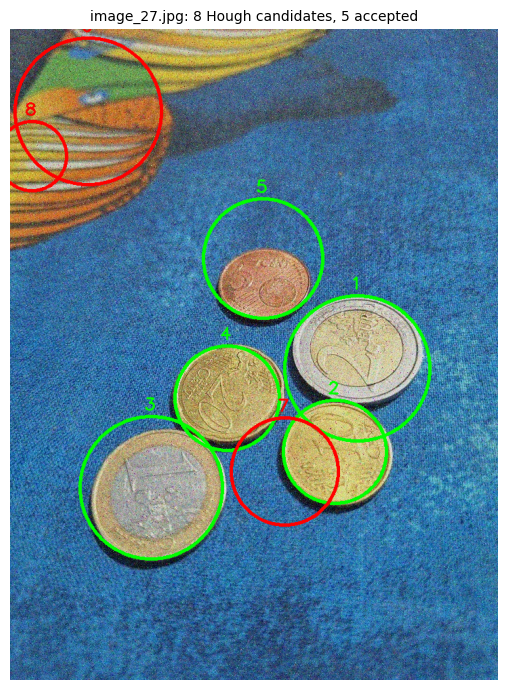

image_27.jpg
  candidate 1: E=0.47  C= 34.2  G=0.82  inside=True  -> accepted
  candidate 2: E=0.93  C= 59.2  G=0.98  inside=True  -> accepted
  candidate 3: E=0.58  C= 47.9  G=0.86  inside=True  -> accepted
  candidate 4: E=0.87  C= 22.7  G=0.98  inside=True  -> accepted
  candidate 5: E=0.29  C= 12.4  G=0.76  inside=True  -> accepted
  candidate 6: E=0.21  C= 14.4  G=0.77  inside=True  -> rejected
  candidate 7: E=0.22  C= 12.5  G=0.72  inside=True  -> rejected
  candidate 8: E=0.26  C=  9.5  G=0.70  inside=False  -> rejected


In [ ]:
def draw_validation(image, info):
    colours = [(0, 255, 0) if item["valid"] else (0, 0, 255) for item in info]
    return draw_circles(image, [item["circle"] for item in info], colours)


def print_diagnostics(filename, info):
    print(filename)
    for i, item in enumerate(info, start=1):
        print(f"  candidate {i}: E={item['edge_support']:.2f}  C={item['contrast']:5.1f}  "
              f"G={item['gradient_alignment']:.2f}  inside={item['inside_image']}  -> {'accepted' if item['valid'] else 'rejected'}")


example_27 = load_image(os.path.join(TARGET_DIR, "image_27.jpg"))
gray_27, blurred_27, edges_27 = preprocess_image(example_27)
candidates_27 = detect_coin_candidates(blurred_27)
accepted_27, info_27 = validate_coin_candidates(gray_27, blurred_27, edges_27, candidates_27)
show([draw_validation(correct_target_colour(example_27), info_27)],
     [f"image_27.jpg: {len(candidates_27)} Hough candidates, {len(accepted_27)} accepted"], figsize=7)
print_diagnostics("image_27.jpg", info_27)

Running Hough + validation on all 142 images, the count changes in 6 of them. Each of these is shown below with its diagnostics; in every case the rejected circles are background structures.

Images where validation removes at least one candidate: 6 / 142


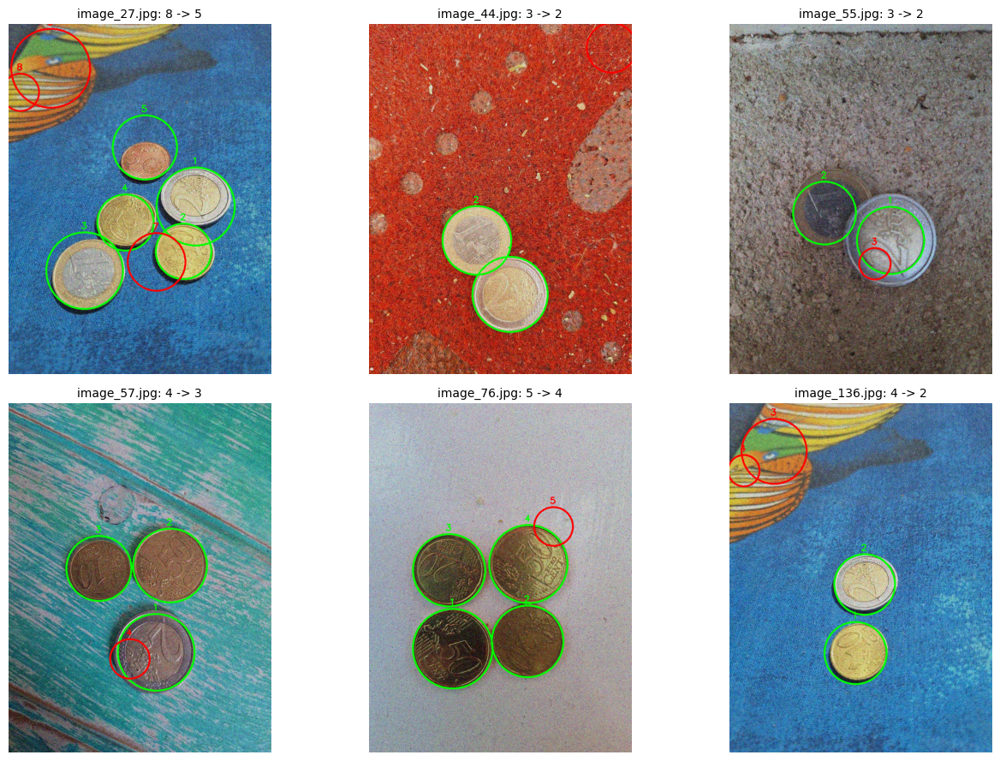

image_27.jpg
  candidate 1: E=0.47  C= 34.2  G=0.82  inside=True  -> accepted
  candidate 2: E=0.93  C= 59.2  G=0.98  inside=True  -> accepted
  candidate 3: E=0.58  C= 47.9  G=0.86  inside=True  -> accepted
  candidate 4: E=0.87  C= 22.7  G=0.98  inside=True  -> accepted
  candidate 5: E=0.29  C= 12.4  G=0.76  inside=True  -> accepted
  candidate 6: E=0.21  C= 14.4  G=0.77  inside=True  -> rejected
  candidate 7: E=0.22  C= 12.5  G=0.72  inside=True  -> rejected
  candidate 8: E=0.26  C=  9.5  G=0.70  inside=False  -> rejected
image_44.jpg
  candidate 1: E=0.82  C= 93.9  G=0.95  inside=True  -> accepted
  candidate 2: E=0.80  C= 84.5  G=0.98  inside=True  -> accepted
  candidate 3: E=0.14  C=  1.1  G=0.62  inside=False  -> rejected
image_55.jpg
  candidate 1: E=0.73  C= 18.7  G=0.98  inside=True  -> accepted
  candidate 2: E=0.32  C= 16.7  G=0.83  inside=True  -> accepted
  candidate 3: E=0.48  C=  6.5  G=0.82  inside=True  -> rejected
image_57.jpg
  candidate 1: E=0.61  C= 13.9  G=0.

In [ ]:
# Hough candidates and their evidence are computed once and reused in the sensitivity analysis (2.6).
hough_evidence = {}
for path in target_paths:
    image = load_image(path)
    gray, blurred, edges = preprocess_image(image)
    _, info = validate_coin_candidates(gray, blurred, edges, detect_coin_candidates(blurred))
    hough_evidence[os.path.basename(path)] = info

changed = [name for name, info in hough_evidence.items() if any(not item["valid"] for item in info)]
print(f"Images where validation removes at least one candidate: {len(changed)} / {len(hough_evidence)}")

show([draw_validation(correct_target_colour(load_image(os.path.join(TARGET_DIR, name))), hough_evidence[name])
      for name in changed],
     [f"{name}: {len(hough_evidence[name])} -> {sum(item['valid'] for item in hough_evidence[name])}" for name in changed],
     ncols=3)
for name in changed:
    print_diagnostics(name, hough_evidence[name])

### 2.4 Second Hough pass for weak boundaries

Validation can only reject proposals; it cannot create a coin that the Hough transform never proposed. Some coins have weak boundaries (silver 1 €/2 € coins on a grey floor, a dark coin on a dark cloth) and do not reach `param2 = 25`. We therefore run two additional, more permissive Hough passes — `param2 = 20` on the same smoothed image, and `param2 = 25` after local contrast enhancement with CLAHE (clip 2, 8×8 tiles) — and accept a new circle only if it satisfies **all** of: edge support ≥ 0.40, gradient alignment ≥ 0.88, contrast ≥ 8, fully inside the image, and centre farther than `0.88 (r + r₀)` from every already accepted circle (no duplicates). The conjunctive rule is stricter than the first one on purpose: these proposals come from a lower vote threshold, so each must be well supported. Candidates are ranked by `E + 0.5 G` so that, when two new circles overlap, the better-supported one wins.

In [ ]:
def recover_candidates(gray, blurred, edges, accepted_circles, min_edge_support=0.40, min_alignment=0.88,
                       min_contrast=8.0, separation=0.88):
    """Validated circles from two permissive Hough passes that do not overlap the accepted ones."""
    grad_x, grad_y, magnitude = compute_gradient_maps(blurred)
    enhanced = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
    enhanced = cv2.GaussianBlur(enhanced, (9, 9), 2)
    proposals = list(detect_coin_candidates(blurred, param2=20)) + list(detect_coin_candidates(enhanced, param2=25))

    scored = []
    for x, y, r in map(lambda c: tuple(map(int, c)), proposals):
        if x - r < 0 or y - r < 0 or x + r >= gray.shape[1] or y + r >= gray.shape[0]:
            continue
        edge_support, alignment = sample_boundary_evidence(edges, x, y, r, grad_x=grad_x, grad_y=grad_y,
                                                           gradient_magnitude=magnitude)
        contrast = compute_region_contrast(gray, x, y, r)
        if edge_support >= min_edge_support and alignment >= min_alignment and contrast >= min_contrast:
            scored.append((edge_support + 0.5 * alignment, (x, y, r), edge_support, alignment, contrast))

    accepted = [tuple(map(int, c)) for c in accepted_circles]
    additions = []
    for _, (x, y, r), edge_support, alignment, contrast in sorted(scored, reverse=True):
        if any(np.hypot(x - x0, y - y0) < separation * (r + r0) for x0, y0, r0 in accepted):
            continue
        accepted.append((x, y, r))
        additions.append({"circle": (x, y, r), "edge_support": edge_support, "gradient_alignment": alignment,
                          "contrast": contrast, "inside_image": True, "valid": True, "source": "recovery"})
    return additions

### 2.5 Local circle refinement

Hough circles are quantised (`dp = 1.2`) and can be off by a few pixels, which matters because the radius is our size measurement and the circle defines the colour regions. Each accepted circle is refined by exhaustive search over centre ±2 px and radius ±4 px (120 angular samples), maximising

$$S = 0.65\,G + 0.35\,E - 0.015\,D,$$

where `G` and `E` are the gradient alignment and edge support of the candidate circle (narrower bands: ±2 and ±1 px) and `D` is the normalised displacement from the Hough solution, a small penalty that keeps the original circle when the evidence is flat. Gradient alignment has the larger weight because it is the more precise cue for the exact rim position. This corrects small quantisation errors only; a circle that is far off (image 27, coin 1) stays off.

In [ ]:
REFINE_ANGLES = np.linspace(0.0, 2.0 * np.pi, 120, endpoint=False).astype(np.float32)
REFINE_COS, REFINE_SIN = np.cos(REFINE_ANGLES), np.sin(REFINE_ANGLES)


def refine_coin_circle(edges, grad_x, grad_y, magnitude, circle, center_search=2, radius_search=4,
                       edge_weight=0.35, gradient_weight=0.65, displacement_weight=0.015):
    """Return the refined (x, y, r) and its diagnostics."""
    x0, y0, r0 = map(int, circle)
    height, width = edges.shape
    best = None
    for dx in range(-center_search, center_search + 1):
        for dy in range(-center_search, center_search + 1):
            for dr in range(-radius_search, radius_search + 1):
                x, y, r = x0 + dx, y0 + dy, r0 + dr
                if r <= 5 or x - r < 0 or y - r < 0 or x + r >= width or y + r >= height:
                    continue
                edge_support, alignment = sample_boundary_evidence(
                    edges, x, y, r, edge_band=1, grad_x=grad_x, grad_y=grad_y, gradient_magnitude=magnitude,
                    gradient_band=2, cos_values=REFINE_COS, sin_values=REFINE_SIN)
                displacement = (abs(dx) + abs(dy)) / (2 * center_search) + abs(dr) / radius_search
                score = gradient_weight * alignment + edge_weight * edge_support - displacement_weight * displacement
                # Ties are broken in favour of the smaller displacement.
                candidate = (score, -abs(dr), -(abs(dx) + abs(dy)), x, y, r, edge_support, alignment)
                if best is None or candidate > best:
                    best = candidate
    if best is None:
        return (x0, y0, r0), {"score": 0.0, "edge_support": 0.0, "gradient_alignment": 0.0, "dx": 0, "dy": 0, "dr": 0}
    score, _, _, x, y, r, edge_support, alignment = best
    return (x, y, r), {"score": score, "edge_support": edge_support, "gradient_alignment": alignment,
                       "dx": x - x0, "dy": y - y0, "dr": r - r0}


def detect_coins(image, recover=True):
    """Full detection: Hough -> validation -> (optional) second pass -> refinement.

    Returns a list of dicts with the Hough circle, the refined circle and the evidence.
    """
    gray, blurred, edges = preprocess_image(image)
    candidates = detect_coin_candidates(blurred)
    accepted, info = validate_coin_candidates(gray, blurred, edges, candidates)
    additions = recover_candidates(gray, blurred, edges, accepted) if recover else []
    grad_x, grad_y, magnitude = compute_gradient_maps(blurred)

    coins = []
    for item in [i for i in info if i["valid"]] + additions:
        refined, refinement = refine_coin_circle(edges, grad_x, grad_y, magnitude, item["circle"])
        coins.append({"hough_circle": item["circle"], "circle": refined, "size_radius": float(refined[2]),
                      "validation": item, "refinement": refinement,
                      "gradient_alignment": refinement["gradient_alignment"]})
    # Sort top-to-bottom, left-to-right so that the printed output is reproducible.
    coins.sort(key=lambda coin: (coin["circle"][1], coin["circle"][0]))
    return {"hough_candidates": len(candidates), "recovered_candidates": len(additions), "coins": coins}

### 2.6 Sensitivity of the validation thresholds

The acceptance thresholds and Hough vote threshold `param2` were chosen during exploratory development. We vary one at a time and count the images whose accepted-coin count differs from the baseline. Gradient alignment uses **0.80 / 0.85 / 0.90**, all within its attainable [0, 1] range; multiplying 0.85 by 1.2 would produce an impossible 1.02 and disable that branch of the rule. Edge support, contrast and `param2` use ±20 %. The table states each tested value. (`param2` requires re-running Hough; the other thresholds only re-apply the rule to stored evidence.)

In [ ]:
BASE_THRESHOLDS = {"min_gradient_alignment": 0.85, "min_edge_support": 0.25, "min_contrast": 10.0}
SENSITIVITY_VALUES = {"min_gradient_alignment": (0.80, 0.85, 0.90),
                      "min_edge_support": (0.20, 0.25, 0.30),
                      "min_contrast": (8.0, 10.0, 12.0)}


def count_accepted(info, **thresholds):
    return sum(item["inside_image"] and has_sufficient_coin_evidence(
        item["edge_support"], item["contrast"], item["gradient_alignment"], **thresholds) for item in info)


base_counts = {name: count_accepted(info, **BASE_THRESHOLDS) for name, info in hough_evidence.items()}
print("Each entry is tested value -> images whose accepted-coin count changes from baseline.")
print(f"{'threshold':<26}{'lower':>18}{'baseline':>18}{'higher':>18}")
for key, values in SENSITIVITY_VALUES.items():
    entries = []
    for value in values:
        thresholds = dict(BASE_THRESHOLDS, **{key: value})
        changes = sum(count_accepted(info, **thresholds) != base_counts[name]
                      for name, info in hough_evidence.items())
        entries.append(f"{value:g} -> {changes}")
    print(f"{key:<26}{entries[0]:>18}{entries[1]:>18}{entries[2]:>18}")

entries = []
for param2 in (20, 25, 30):
    changes = 0
    for path in target_paths:
        gray, blurred, edges = preprocess_image(load_image(path))
        accepted, _ = validate_coin_candidates(gray, blurred, edges, detect_coin_candidates(blurred, param2=param2))
        changes += len(accepted) != base_counts[os.path.basename(path)]
    entries.append(f"{param2} -> {changes}")
print(f"{'hough param2':<26}{entries[0]:>18}{entries[1]:>18}{entries[2]:>18}")

Each entry is tested value -> images whose accepted-coin count changes from baseline.
threshold                              lower          baseline            higher
min_gradient_alignment              0.8 -> 1         0.85 -> 0          0.9 -> 1
min_edge_support                    0.2 -> 1         0.25 -> 0          0.3 -> 1
min_contrast                          8 -> 1           10 -> 0           12 -> 0
hough param2                        20 -> 13           25 -> 0          30 -> 22


In this sweep, changing edge support or contrast affects few image counts: these thresholds only matter when the gradient test fails. The tested `param2` changes affect more images, motivating the separately validated recovery pass. These are count-stability diagnostics for the stated perturbations, not an accuracy comparison or a ranking of every detector parameter.

## 3. Coin classification

The denomination is decided in two stages: **material group** from colour (Section 3.1–3.3), then **physical size** within the group (Section 3.4). Keeping the stages separate makes the errors interpretable: a wrong material restricts the size search to the wrong set of diameters.

### 3.1 Colour features

For each detected circle three regions are defined in normalised radial coordinates `ρ = d / r`: the central disk `ρ ≤ 0.40`, the outer ring `0.78 ≤ ρ ≤ 0.90` and the inner material disk `ρ ≤ 0.68`. The gap between 0.68 and 0.78 skips the bimetal transition, and stopping at 0.90 avoids the rim and its shadow. Features:

* `inner_gb` — `G − B` of the component-wise median RGB colour in the inner disk, normalised by the sum of those three median components. Copper is reddish (small `G − B`), the gold alloy is yellowish (larger `G − B`); dividing by the sum removes most of the dependence on illumination intensity.
* `center_gb`, `ring_gb` — the same feature on the centre and on the ring, to tell 1 € (gold ring, silver centre) from 2 € (silver ring, gold centre).
* `saturation_gap`, `hue_gap`, `chroma_distance` — differences between centre and ring, in HSV saturation, in hue (circular median on OpenCV's 0–180 hue circle) and in chromaticity. Before HSV extraction, the crop receives a clipped additive brightness shift to bring the coin median grayscale to 128. Bimetallic coins tend to have a larger centre/ring difference; engraving, lighting and imperfect regions can also produce differences in monometallic coins.

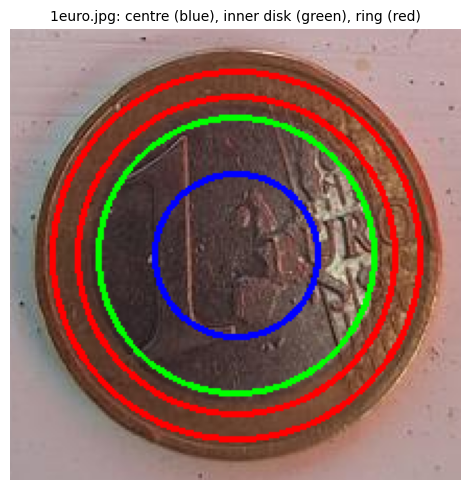

In [ ]:
CENTER_RADIUS, RING_INNER_RADIUS, RING_OUTER_RADIUS, INNER_RADIUS = 0.40, 0.78, 0.90, 0.68

# OpenCV hue is an integer on a circle of period 180: the exact circular median is cheap with a lookup table.
HUE_DOMAIN = np.arange(180, dtype=np.float64)
HUE_CIRCULAR_DISTANCE = np.minimum(np.abs(HUE_DOMAIN[:, None] - HUE_DOMAIN[None, :]),
                                   180.0 - np.abs(HUE_DOMAIN[:, None] - HUE_DOMAIN[None, :]))


def extract_circular_region(image, x, y, r, padding=0.02):
    """Local crop around a circle and the normalised radial distance of each crop pixel."""
    height, width = image.shape[:2]
    crop_radius = int(np.ceil(r * (1.0 + padding)))
    x0, x1 = max(0, x - crop_radius), min(width, x + crop_radius + 1)
    y0, y1 = max(0, y - crop_radius), min(height, y + crop_radius + 1)
    crop = image[y0:y1, x0:x1].copy()
    yy, xx = np.ogrid[:crop.shape[0], :crop.shape[1]]
    radial = np.sqrt((xx - (x - x0)) ** 2 + (yy - (y - y0)) ** 2) / max(float(r), 1.0)
    return crop, radial


def median_chromaticity(image_bgr, mask):
    """Median RGB colour of the masked pixels, normalised so that R + G + B = 1."""
    pixels = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)[mask]
    if pixels.size == 0:
        return np.full(3, 1 / 3, dtype=np.float32)
    median = np.median(pixels, axis=0)
    return median / (median.sum() + 1e-6)


def circular_hue_difference(h1, h2):
    difference = abs(float(h1) - float(h2))
    return min(difference, 180.0 - difference)


def circular_median_hue(hue_values):
    """Hue minimising the summed circular distance to all samples (no wrap-around bias)."""
    values = np.asarray(hue_values, dtype=np.uint8).ravel()
    if values.size == 0:
        return 0.0
    counts = np.bincount(values, minlength=180).astype(np.float64)
    costs = HUE_CIRCULAR_DISTANCE @ counts
    candidates = np.flatnonzero(np.isclose(costs, costs.min(), rtol=0, atol=1e-9))
    resultant = np.sum(counts * np.exp(2j * np.pi * HUE_DOMAIN / 180.0))
    if abs(resultant) <= 1e-9:
        return float(candidates[0])
    mean_hue = (np.angle(resultant) * 180.0 / (2.0 * np.pi)) % 180.0
    distances = np.minimum(np.abs(candidates - mean_hue), 180.0 - np.abs(candidates - mean_hue))
    return float(candidates[np.argmin(distances)])


def median_hsv(image_bgr, mask):
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    if not np.any(mask):
        return 0.0, 0.0
    return circular_median_hue(hsv[:, :, 0][mask]), float(np.median(hsv[:, :, 1][mask]))


def normalize_local_brightness(image_bgr, mask, target_median=128.0):
    """Additive brightness shift so that the coin has a fixed median gray level (for the HSV features)."""
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)[mask]
    if gray.size == 0:
        return image_bgr.copy()
    return np.clip(image_bgr.astype(np.float32) + (target_median - float(np.median(gray))), 0, 255).astype(np.uint8)


def compute_coin_colour_features(image_bgr, x, y, r):
    crop, radial = extract_circular_region(image_bgr, x, y, r)
    center_mask = radial <= CENTER_RADIUS
    ring_mask = (radial >= RING_INNER_RADIUS) & (radial <= RING_OUTER_RADIUS)
    inner_mask = radial <= INNER_RADIUS

    center_chroma = median_chromaticity(crop, center_mask)
    ring_chroma = median_chromaticity(crop, ring_mask)
    inner_chroma = median_chromaticity(crop, inner_mask)

    normalized = normalize_local_brightness(crop, radial <= RING_OUTER_RADIUS)
    center_hue, center_saturation = median_hsv(normalized, center_mask)
    ring_hue, ring_saturation = median_hsv(normalized, ring_mask)

    return {
        "center_gb": float(center_chroma[1] - center_chroma[2]),
        "ring_gb": float(ring_chroma[1] - ring_chroma[2]),
        "inner_gb": float(inner_chroma[1] - inner_chroma[2]),
        "chroma_distance": float(np.linalg.norm(center_chroma - ring_chroma)),
        "hue_gap": circular_hue_difference(center_hue, ring_hue),
        "saturation_gap": abs(center_saturation - ring_saturation),
    }


# Illustration of the three regions on the 1 euro reference coin.
reference_1euro = load_image(os.path.join(REFERENCE_DIR, "1euro.jpg"))
ref_detection = detect_coins(reference_1euro, recover=False)["coins"][0]
x, y, r = ref_detection["circle"]
illustration = reference_1euro.copy()
for rho, colour in ((CENTER_RADIUS, (255, 0, 0)), (INNER_RADIUS, (0, 255, 0)),
                    (RING_INNER_RADIUS, (0, 0, 255)), (RING_OUTER_RADIUS, (0, 0, 255))):
    cv2.circle(illustration, (x, y), int(rho * r), colour, 2)
show([illustration[y - r - 10:y + r + 10, x - r - 10:x + r + 10]],
     ["1euro.jpg: centre (blue), inner disk (green), ring (red)"], figsize=5)

### 3.2 Calibration on the reference set

The single coin of each reference image is detected with the pipeline of Section 2 (choosing the circle closest to the image centre, since every reference contains one coin) and its colour features are computed. The rules are then set from the eight feature vectors:

* **Copper / gold strong limits** — the largest `inner_gb` of the three copper references and the smallest of the three gold references. Values below the first are copper, above the second are gold; the interval in between is ambiguous.
* **Bimetal rule** — a coin is bimetallic if its centre/ring saturation gap exceeds a threshold placed 20 % of the way between the largest monometal reference gap and the smallest bimetal reference gap. It is placed close to the monometal side so that bimetal coins are still recognised when target lighting reduces the centre/ring contrast. A second, stricter cue (chromaticity distance one third of the way across the reference gap, hue gap ≥ 15, i.e. ≈ 30°, and gradient alignment ≥ 0.80, i.e. a well-defined circle so that the regions are not contaminated) catches bimetal coins whose saturation gap is washed out.
* **1 € vs 2 €** — on a bimetal coin, the region with the larger `G − B` is the gold one: gold ring → 1 €, gold centre → 2 €.

In [ ]:
REFERENCE_VALUES = {"1cent": 0.01, "2cent": 0.02, "5cent": 0.05, "10cent": 0.10,
                    "20cent": 0.20, "50cent": 0.50, "1euro": 1.00, "2euro": 2.00}
COPPER_REFERENCE_NAMES = ["1cent", "2cent", "5cent"]
GOLD_REFERENCE_NAMES = ["10cent", "20cent", "50cent"]
BIMETAL_REFERENCE_NAMES = ["1euro", "2euro"]
MONOMETAL_REFERENCE_NAMES = COPPER_REFERENCE_NAMES + GOLD_REFERENCE_NAMES


def detect_reference_circle(reference_image):
    """The refined circle closest to the image centre (every reference image contains one coin)."""
    coins = detect_coins(reference_image, recover=False)["coins"]
    if not coins:
        raise RuntimeError("No coin found in reference image")
    height, width = reference_image.shape[:2]
    best = min(coins, key=lambda c: (c["circle"][0] - width / 2) ** 2 + (c["circle"][1] - height / 2) ** 2)
    return best["circle"]


reference_circles, reference_features = {}, {}
for name in REFERENCE_VALUES:
    image = load_image(os.path.join(REFERENCE_DIR, f"{name}.jpg"))
    x, y, r = detect_reference_circle(image)
    reference_circles[name] = (x, y, r)
    reference_features[name] = compute_coin_colour_features(image, x, y, r)

ref = reference_features
COPPER_GB_LIMIT = max(ref[n]["inner_gb"] for n in COPPER_REFERENCE_NAMES)
GOLD_GB_LIMIT = min(ref[n]["inner_gb"] for n in GOLD_REFERENCE_NAMES)
AMBIGUOUS_GB_MIDPOINT = 0.5 * (COPPER_GB_LIMIT + GOLD_GB_LIMIT)

monometal_max_sat = max(ref[n]["saturation_gap"] for n in MONOMETAL_REFERENCE_NAMES)
bimetal_min_sat = min(ref[n]["saturation_gap"] for n in BIMETAL_REFERENCE_NAMES)
SATURATION_GAP_THRESHOLD = monometal_max_sat + 0.20 * (bimetal_min_sat - monometal_max_sat)

monometal_max_chroma = max(ref[n]["chroma_distance"] for n in MONOMETAL_REFERENCE_NAMES)
bimetal_min_chroma = min(ref[n]["chroma_distance"] for n in BIMETAL_REFERENCE_NAMES)
FALLBACK_CHROMA_DISTANCE = monometal_max_chroma + (bimetal_min_chroma - monometal_max_chroma) / 3.0
FALLBACK_HUE_GAP = 15.0
FALLBACK_MIN_GRADIENT_ALIGNMENT = 0.80

print("Reference features:")
print(f"{'coin':>7} {'inner_gb':>9} {'sat gap':>8} {'hue gap':>8} {'chroma d':>9}")
for name, f in reference_features.items():
    print(f"{name:>7} {f['inner_gb']:9.3f} {f['saturation_gap']:8.1f} {f['hue_gap']:8.1f} {f['chroma_distance']:9.3f}")
print(f"\nCopper limit (G-B) <= {COPPER_GB_LIMIT:.3f} | gold limit >= {GOLD_GB_LIMIT:.3f} | midpoint {AMBIGUOUS_GB_MIDPOINT:.3f}")
print(f"Bimetal saturation-gap threshold: {SATURATION_GAP_THRESHOLD:.1f} "
      f"(monometal max {monometal_max_sat:.1f}, bimetal min {bimetal_min_sat:.1f})")
print(f"Fallback bimetal rule: chroma distance >= {FALLBACK_CHROMA_DISTANCE:.3f}, hue gap >= {FALLBACK_HUE_GAP}, "
      f"gradient alignment >= {FALLBACK_MIN_GRADIENT_ALIGNMENT}")

Reference features:
   coin  inner_gb  sat gap  hue gap  chroma d
  1cent     0.073      5.0      0.0     0.021
  2cent     0.063      5.0      0.0     0.012
  5cent     0.043     14.0      1.0     0.017
 10cent     0.122      5.0      0.0     0.008
 20cent     0.099      3.0      1.0     0.004
 50cent     0.106      2.0      1.0     0.003
  1euro     0.010     49.0      7.0     0.106
  2euro     0.091     50.0      8.0     0.087

Copper limit (G-B) <= 0.073 | gold limit >= 0.099 | midpoint 0.086
Bimetal saturation-gap threshold: 21.0 (monometal max 14.0, bimetal min 49.0)
Fallback bimetal rule: chroma distance >= 0.043, hue gap >= 15.0, gradient alignment >= 0.8


In [ ]:
def classify_material_group(features, gradient_alignment, monometal_threshold=None):
    """'copper', 'gold', '1euro' or '2euro'.

    monometal_threshold: G-B split between copper and gold. None -> reference rules
    (strong limits + midpoint); a float -> that single threshold (Section 3.3).
    """
    clear_bimetal = features["saturation_gap"] >= SATURATION_GAP_THRESHOLD
    weak_bimetal = (features["chroma_distance"] >= FALLBACK_CHROMA_DISTANCE
                    and features["hue_gap"] >= FALLBACK_HUE_GAP
                    and gradient_alignment >= FALLBACK_MIN_GRADIENT_ALIGNMENT)
    if clear_bimetal or weak_bimetal:
        return "1euro" if features["ring_gb"] > features["center_gb"] else "2euro"

    inner_gb = features["inner_gb"]
    if monometal_threshold is not None:
        return "copper" if inner_gb < monometal_threshold else "gold"
    if inner_gb <= COPPER_GB_LIMIT:
        return "copper"
    if inner_gb >= GOLD_GB_LIMIT:
        return "gold"
    return "copper" if inner_gb < AMBIGUOUS_GB_MIDPOINT else "gold"


def expected_material_group(value):
    if value in (0.01, 0.02, 0.05):
        return "copper"
    if value in (0.10, 0.20, 0.50):
        return "gold"
    return "1euro" if value == 1.00 else "2euro"


# Sanity check: the rules must at least reproduce the eight images they were calibrated on.
print("Reference consistency (calibration data, not a test):")
for name, value in REFERENCE_VALUES.items():
    predicted = classify_material_group(reference_features[name], gradient_alignment=1.0)
    expected = expected_material_group(value)
    print(f"  {name:>6}: expected {expected:<6} predicted {predicted:<6} {'OK' if predicted == expected else 'MISMATCH'}")

Reference consistency (calibration data, not a test):
   1cent: expected copper predicted copper OK
   2cent: expected copper predicted copper OK
   5cent: expected copper predicted copper OK
  10cent: expected gold   predicted gold   OK
  20cent: expected gold   predicted gold   OK
  50cent: expected gold   predicted gold   OK
   1euro: expected 1euro  predicted 1euro  OK
   2euro: expected 2euro  predicted 2euro  OK


### 3.3 Running on the target set, and adapting the copper/gold split

The target images are now analysed: detection (Section 2), colour features on the colour-corrected image, material group. Two analyses are kept — without and with the second Hough pass — so that the self-evaluation can measure what the second pass contributes.

**The copper/gold threshold is adapted to the target set.** The reference photos were taken on white paper under a pinkish light; the targets are on many different surfaces, with a colour cast that the channel correction does not remove. The histogram below shows that the target `inner_gb` values are shifted with respect to the reference limits: the reference split (midpoint 0.086) falls inside the main mode of the target distribution. We therefore replace it with an **Otsu threshold computed on the target `inner_gb` values of the coins classified as monometallic** — an unsupervised choice that uses no label. Its limitation is visible in the same histogram: the distribution is broad rather than clearly bimodal, so the split is approximate and some coins near the threshold are inevitably misassigned.

During exploratory development we preferred the split with higher **denomination-multiset F1**, while also inspecting per-image monetary errors. This approximates denomination matching but cannot verify spatial instance labels. Section 5 compares the variants and Section 6 states the monetary trade-off; the selection follows the development protocol above.

Coins found: 313 (of which 5 from the second Hough pass)
Reference midpoint: 0.0861 | target Otsu threshold: 0.1014
Material groups with the reference split: {'copper': 92, 'gold': 150, '1euro': 45, '2euro': 26}
Material groups with the target Otsu split: {'copper': 138, 'gold': 104, '1euro': 45, '2euro': 26}


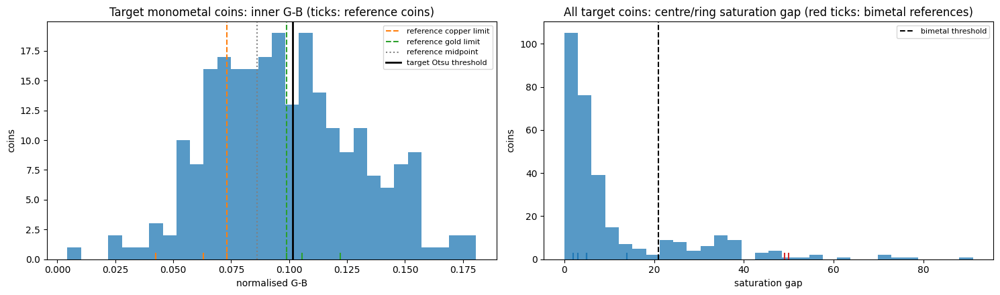

In [ ]:
def analyse_target_image(path, recover=True):
    """Detection + colour features + material group for one target image."""
    raw = load_image(path)
    result = detect_coins(raw, recover=recover)
    colour_image = correct_target_colour(raw)
    for coin in result["coins"]:
        x, y, r = coin["circle"]
        coin["colour_features"] = compute_coin_colour_features(colour_image, x, y, r)
        coin["material_group"] = classify_material_group(coin["colour_features"], coin["gradient_alignment"])
    result.update(filename=os.path.basename(path), path=path)
    return result


def otsu_threshold_1d(values, bins=256):
    """1-D Otsu threshold (maximum between-class variance) on a list of values."""
    counts, edges = np.histogram(np.asarray(values, dtype=np.float64), bins=bins)
    p = counts / max(counts.sum(), 1)
    centres = 0.5 * (edges[:-1] + edges[1:])
    w0 = np.cumsum(p)
    mu0 = np.cumsum(p * centres)
    mu_total = mu0[-1]
    denominator = w0 * (1.0 - w0)
    sigma_b = np.zeros_like(denominator)
    valid = denominator > 1e-12
    sigma_b[valid] = (mu_total * w0[valid] - mu0[valid]) ** 2 / denominator[valid]
    return float(edges[int(np.argmax(sigma_b[:-1])) + 1])


def apply_monometal_threshold(results, threshold):
    """Re-split the monometallic coins of every image with a single G-B threshold (in place)."""
    for result in results.values():
        for coin in result["coins"]:
            if coin["material_group"] in {"copper", "gold"}:
                coin["material_group"] = classify_material_group(coin["colour_features"], coin["gradient_alignment"],
                                                                 monometal_threshold=threshold)


analysis_no_recovery = {os.path.basename(p): analyse_target_image(p, recover=False) for p in target_paths}
analysis_reference_split = {os.path.basename(p): analyse_target_image(p, recover=True) for p in target_paths}

monometal_gb = [coin["colour_features"]["inner_gb"] for result in analysis_reference_split.values()
                for coin in result["coins"] if coin["material_group"] in {"copper", "gold"}]
TARGET_OTSU_THRESHOLD = otsu_threshold_1d(monometal_gb)

target_analysis = copy.deepcopy(analysis_reference_split)   # the final pipeline
apply_monometal_threshold(target_analysis, TARGET_OTSU_THRESHOLD)

print(f"Coins found: {sum(len(r['coins']) for r in target_analysis.values())} "
      f"(of which {sum(r['recovered_candidates'] for r in target_analysis.values())} from the second Hough pass)")
print(f"Reference midpoint: {AMBIGUOUS_GB_MIDPOINT:.4f} | target Otsu threshold: {TARGET_OTSU_THRESHOLD:.4f}")
print("Material groups with the reference split:",
      dict(Counter(c["material_group"] for r in analysis_reference_split.values() for c in r["coins"])))
print("Material groups with the target Otsu split:",
      dict(Counter(c["material_group"] for r in target_analysis.values() for c in r["coins"])))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].hist(monometal_gb, bins=30, alpha=0.75)
axes[0].axvline(COPPER_GB_LIMIT, ls="--", color="C1", label="reference copper limit")
axes[0].axvline(GOLD_GB_LIMIT, ls="--", color="C2", label="reference gold limit")
axes[0].axvline(AMBIGUOUS_GB_MIDPOINT, ls=":", color="gray", label="reference midpoint")
axes[0].axvline(TARGET_OTSU_THRESHOLD, color="black", lw=2, label="target Otsu threshold")
for name in MONOMETAL_REFERENCE_NAMES:
    axes[0].scatter(reference_features[name]["inner_gb"], 0, marker="|", s=200, color="C1" if name in COPPER_REFERENCE_NAMES else "C2")
axes[0].set(title="Target monometal coins: inner G-B (ticks: reference coins)", xlabel="normalised G-B", ylabel="coins")
axes[0].legend(fontsize=8)

saturation_gaps = [c["colour_features"]["saturation_gap"] for r in target_analysis.values() for c in r["coins"]]
axes[1].hist(saturation_gaps, bins=30, alpha=0.75)
axes[1].axvline(SATURATION_GAP_THRESHOLD, ls="--", color="black", label="bimetal threshold")
for name in REFERENCE_VALUES:
    axes[1].scatter(reference_features[name]["saturation_gap"], 0, marker="|", s=200,
                    color="C3" if name in BIMETAL_REFERENCE_NAMES else "C0")
axes[1].set(title="All target coins: centre/ring saturation gap (red ticks: bimetal references)", xlabel="saturation gap", ylabel="coins")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 3.4 Denomination from physical size

Within a material group the denominations differ by diameter ([ECB](https://www.ecb.europa.eu/euro/coins/common/html/index.en.html)):

| Coin | 1c | 2c | 5c | 10c | 20c | 50c | 1 € | 2 € |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Diameter (mm) | 16.25 | 18.75 | 21.25 | 19.75 | 22.25 | 24.25 | 23.25 | 25.75 |

Consecutive sizes in a group differ by only 9–15 %, so the pixel radius must be converted to millimetres with the scale `s` (px/mm) of the image, which depends on the camera distance and is **not known**. It is estimated from the coins themselves:

* Every coin proposes one scale per denomination compatible with its material (`s = 2r / D`). For each proposed scale, every coin is assigned its best-fitting compatible denomination and the relative radius error is recorded; the scale minimising `Σ errors + 0.5 · max error` wins (the max term penalises a scale that fits most coins but badly misfits one). A unique numerical minimum often exists with several detections, but it does not establish that the scale is physically correct: wrong materials, perspective and radius errors can select a wrong solution. A correctly classified bimetallic coin contributes a known-diameter constraint.
* A single monometallic coin cannot determine both its denomination and the scale. For the 48 of 142 images with exactly one detected coin classified as monometallic, we use the median of the uniquely resolved multi-detection scales. This subset is defined by predictions; some images actually contain missed additional coins (Section 5.2). The box plot below shows why the reference set cannot serve this purpose either: the eight reference coins were photographed at scales between 6.2 and 8.4 px/mm, and the estimated multi-detection target scales span 6.2–9.2 px/mm (10th–90th percentile). These are model-derived scale estimates, not measured camera distances. With this spread, several sizes remain plausible for most single coins; this is the main limitation of the pipeline and it is quantified in Section 5.
* Numerical ties between scales (three images) are resolved by proximity to the same median.

Reference scales (px/mm): {'1cent': 7.02, '2cent': 7.15, '5cent': 6.78, '10cent': 6.68, '20cent': 6.2, '50cent': 6.27, '1euro': 8.43, '2euro': 6.37}
Multi-coin target images with a unique scale: 80; median 7.519 px/mm, 10th-90th percentile 6.17-9.17, CV 14.7%
Images with one predicted monometal coin: 48; of these, 39 admit more than one denomination within the 10th-90th percentile scale range


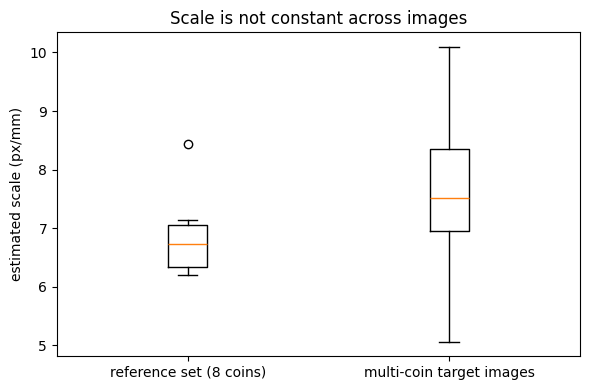

In [ ]:
COIN_DIAMETERS_MM = {0.01: 16.25, 0.02: 18.75, 0.05: 21.25, 0.10: 19.75,
                     0.20: 22.25, 0.50: 24.25, 1.00: 23.25, 2.00: 25.75}
GROUP_DENOMINATIONS = {"copper": [0.01, 0.02, 0.05], "gold": [0.10, 0.20, 0.50], "1euro": [1.00], "2euro": [2.00]}
SCALE_SCORE_TOLERANCE = 1e-9


def relative_radius_error(radius, scale, value):
    expected = scale * COIN_DIAMETERS_MM[value] / 2.0
    return abs(radius - expected) / max(expected, 1e-9)


def best_scale_hypotheses(coins):
    """All (score, max error, scale) tuples with the minimum score over the discrete hypothesis set."""
    if not coins:
        return []
    scales = sorted({2.0 * c["size_radius"] / COIN_DIAMETERS_MM[v]
                     for c in coins for v in GROUP_DENOMINATIONS[c["material_group"]]})
    solutions = []
    for scale in scales:
        errors = [min(relative_radius_error(c["size_radius"], scale, v) for v in GROUP_DENOMINATIONS[c["material_group"]])
                  for c in coins]
        solutions.append((sum(errors) + 0.5 * max(errors), max(errors), scale))
    minimum = min(s[0] for s in solutions)
    return [s for s in solutions if abs(s[0] - minimum) <= SCALE_SCORE_TOLERANCE]


def estimate_image_scale(coins, tie_reference):
    solutions = best_scale_hypotheses(coins)
    if not solutions:
        return None
    return min(solutions, key=lambda s: (abs(np.log(s[2] / tie_reference)), s[1], s[2]))[2]


def calibrate_fallback_scale(results):
    """Median of the uniquely resolved scales of multi-coin images (no labels involved)."""
    scales = [best_scale_hypotheses(r["coins"])[0][2] for r in results.values()
              if len(r["coins"]) >= 2 and len(best_scale_hypotheses(r["coins"])) == 1]
    if not scales:
        raise RuntimeError("No multi-coin image with a unique scale")
    return float(np.median(scales)), scales


def assign_denomination(coin, scale):
    return min(GROUP_DENOMINATIONS[coin["material_group"]],
               key=lambda v: relative_radius_error(coin["size_radius"], scale, v))


def assign_all_denominations(results, fallback_scale):
    """Scale, denominations and partial amount for every image (in place)."""
    for result in results.values():
        coins = result["coins"]
        if not coins:
            result.update(scale=None, scale_source="no coins", partial_amount=0.0)
            continue
        hypotheses = best_scale_hypotheses(coins)
        if len(coins) == 1 and coins[0]["material_group"] in {"copper", "gold"}:
            scale, source = fallback_scale, "single monometal: batch median"
        else:
            scale = estimate_image_scale(coins, tie_reference=fallback_scale)
            source = "tie resolved by batch median" if len(hypotheses) > 1 else "unique scale hypothesis"
        for coin in coins:
            coin["predicted_value"] = assign_denomination(coin, scale)
        result.update(scale=scale, scale_source=source, partial_amount=sum(c["predicted_value"] for c in coins))


REFERENCE_SCALES = {n: reference_circles[n][2] / (COIN_DIAMETERS_MM[v] / 2.0) for n, v in REFERENCE_VALUES.items()}
FALLBACK_SCALE, multi_coin_scales = calibrate_fallback_scale(target_analysis)
p10, p90 = np.percentile(multi_coin_scales, [10, 90])
assign_all_denominations(target_analysis, FALLBACK_SCALE)

print("Reference scales (px/mm):", {n: round(s, 2) for n, s in REFERENCE_SCALES.items()})
print(f"Multi-coin target images with a unique scale: {len(multi_coin_scales)}; "
      f"median {FALLBACK_SCALE:.3f} px/mm, 10th-90th percentile {p10:.2f}-{p90:.2f}, "
      f"CV {np.std(multi_coin_scales) / np.mean(multi_coin_scales):.1%}")
single = [r for r in target_analysis.values() if r["scale_source"].startswith("single")]
for result in single:
    coin = result["coins"][0]
    coin["plausible_values"] = [v for v in GROUP_DENOMINATIONS[coin["material_group"]]
                                if p10 <= 2 * coin["size_radius"] / COIN_DIAMETERS_MM[v] <= p90]
print(f"Images with one predicted monometal coin: {len(single)}; of these, "
      f"{sum(len(r['coins'][0]['plausible_values']) > 1 for r in single)} admit more than one denomination "
      f"within the 10th-90th percentile scale range")

plt.figure(figsize=(6, 4))
plt.boxplot([list(REFERENCE_SCALES.values()), multi_coin_scales])
plt.xticks([1, 2], ["reference set (8 coins)", "multi-coin target images"])
plt.ylabel("estimated scale (px/mm)")
plt.title("Scale is not constant across images")
plt.tight_layout()
plt.show()

## 4. Results in the required format

In [ ]:
ordered_results = sorted(target_analysis.values(), key=lambda r: image_number(r["path"]))
TOTAL_AMOUNT = 0.0
for result in ordered_results:
    print(f"{result['filename']} - {len(result['coins'])} coin(s) found:")
    for i, coin in enumerate(result["coins"], start=1):
        print(f"  Coin {i} {{value: {coin['predicted_value']:.3f}}}")
    print(f"  Partial Amount {{value: {result['partial_amount']:.3f}}}")
    TOTAL_AMOUNT += result["partial_amount"]
print(f"\nTotal Amount: {TOTAL_AMOUNT:.2f} €")

image_1.jpg - 3 coin(s) found:
  Coin 1 {value: 0.050}
  Coin 2 {value: 0.020}
  Coin 3 {value: 0.010}
  Partial Amount {value: 0.080}
image_2.jpg - 1 coin(s) found:
  Coin 1 {value: 0.100}
  Partial Amount {value: 0.100}
image_3.jpg - 6 coin(s) found:
  Coin 1 {value: 0.100}
  Coin 2 {value: 0.050}
  Coin 3 {value: 0.020}
  Coin 4 {value: 0.100}
  Coin 5 {value: 0.050}
  Coin 6 {value: 0.100}
  Partial Amount {value: 0.420}
image_4.jpg - 1 coin(s) found:
  Coin 1 {value: 0.050}
  Partial Amount {value: 0.050}
image_5.jpg - 1 coin(s) found:
  Coin 1 {value: 0.100}
  Partial Amount {value: 0.100}
image_6.jpg - 1 coin(s) found:
  Coin 1 {value: 0.020}
  Partial Amount {value: 0.020}
image_7.jpg - 3 coin(s) found:
  Coin 1 {value: 0.050}
  Coin 2 {value: 0.500}
  Coin 3 {value: 0.500}
  Partial Amount {value: 1.050}
image_8.jpg - 1 coin(s) found:
  Coin 1 {value: 0.050}
  Partial Amount {value: 0.050}
image_9.jpg - 1 coin(s) found:
  Coin 1 {value: 0.050}
  Partial Amount {value: 0.050}
i

Images: 142 | coins: 313 | total: 124.94 €
Images using the batch-median scale (one predicted monometal coin): 48
Mean |dx|, |dy|, |dr| of the local refinement: [0.8  0.83 0.73] px


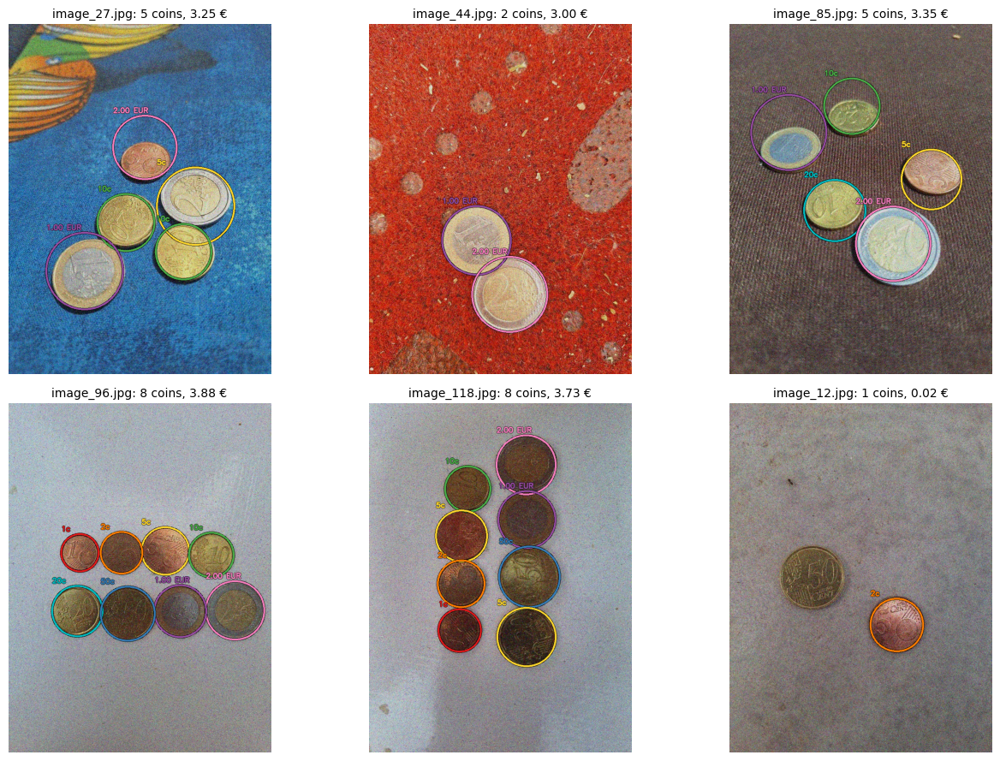

In [ ]:
DENOMINATION_COLORS_BGR = {0.01: (28, 26, 228), 0.02: (0, 127, 255), 0.05: (47, 217, 255), 0.10: (74, 175, 77),
                           0.20: (196, 191, 0), 0.50: (184, 126, 55), 1.00: (163, 78, 152), 2.00: (191, 129, 247)}


def denomination_label(value):
    return f"{value:.2f} EUR" if value >= 1.0 else f"{int(round(value * 100))}c"


def draw_final_predictions(result):
    """Colour-corrected image with one coloured circle and a text label per coin."""
    image = correct_target_colour(load_image(result["path"]))
    for coin in result["coins"]:
        x, y, r = coin["circle"]
        colour = DENOMINATION_COLORS_BGR[coin["predicted_value"]]
        cv2.circle(image, (x, y), r, (0, 0, 0), 5)
        cv2.circle(image, (x, y), r, colour, 3)
        origin = (x - r, max(25, y - r - 8))
        cv2.putText(image, denomination_label(coin["predicted_value"]), origin, cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 0), 4, cv2.LINE_AA)
        cv2.putText(image, denomination_label(coin["predicted_value"]), origin, cv2.FONT_HERSHEY_SIMPLEX, 0.65, colour, 2, cv2.LINE_AA)
    return image


refinement = np.array([[abs(c["refinement"][k]) for k in ("dx", "dy", "dr")] for r in ordered_results for c in r["coins"]])
print(f"Images: {len(ordered_results)} | coins: {sum(len(r['coins']) for r in ordered_results)} | total: {TOTAL_AMOUNT:.2f} €")
print(f"Images using the batch-median scale (one predicted monometal coin): {len(single)}")
print(f"Mean |dx|, |dy|, |dr| of the local refinement: {refinement.mean(axis=0).round(2)} px")

examples = ["image_27.jpg", "image_44.jpg", "image_85.jpg", "image_96.jpg", "image_118.jpg", "image_12.jpg"]
show([draw_final_predictions(target_analysis[n]) for n in examples],
     [f"{n}: {len(target_analysis[n]['coins'])} coins, {target_analysis[n]['partial_amount']:.2f} €" for n in examples], ncols=3)

The assignment gives one worked example: `image_85.jpg` contains five coins for 3.35 € (its `0.005` line is read as 0.05 €).

In [ ]:
example = target_analysis["image_85.jpg"]
values = sorted(c["predicted_value"] for c in example["coins"])
print("image_85.jpg predicted:", values, f"-> {example['partial_amount']:.2f} € (expected 3.35 €)")
print("Example check:", "PASSED" if values == [0.05, 0.10, 0.20, 1.00, 2.00] else "FAILED")

image_85.jpg predicted: [0.05, 0.1, 0.2, 1.0, 2.0] -> 3.35 € (expected 3.35 €)
Example check: PASSED


## 5. Self-evaluation

To evaluate our predictions, our group manually annotated the target-set images by visual inspection, recording the coin count and denominations for each image in sheet `Ground Truth` of [coin_ground_truth.xlsm](https://drive.google.com/file/d/1pu-npj62XFRzC0RI3n_5Gp3xKpLNO6h_/view?usp=drivesdk). Download this file into the working directory or `MyDrive/Colab Notebooks/`. The loader checks coverage, permitted denominations, counts and amount arithmetic. The pipeline above runs without this file; evaluation and appendix comparisons require it.

The spreadsheet lists denominations **without object positions**, so matching is within each image and ignores order:

* **count accuracy** — fraction of images with the correct detected count, on all 142 rows, assuming the listed counts are reliable;
* **exact composition** — fraction with exactly the right multiset of denominations;
* **denomination-multiset precision / recall / F1** — matching denomination occurrences per image, then pooling counts across images. These cannot establish localisation accuracy or detect all swapped instance labels;
* **MAE / RMSE** — absolute and squared per-image monetary errors; **total bias** — sum of signed image errors, reported separately because errors can cancel.

Primary composition, denomination-multiset precision/recall/F1 and monetary metrics use the 130 rows with empty `Notes`. The remaining 12 rows were flagged for further checking during manual annotation (`check` / `check after`), so their denomination labels are treated as uncertain and excluded from the primary evaluation. Results on all 142 images are also reported as provisional. Count accuracy uses all 142 images, assuming the annotated counts are reliable. Empty notes do not guarantee correct labels, and `Reviewed` is not used. All comparisons use these same scopes and the development protocol stated at the start.

In [ ]:
try:
    import pandas as pd
except ImportError:
    pd = None

GROUND_TRUTH_CANDIDATES = ["./coin_ground_truth.xlsm", "/content/drive/MyDrive/Colab Notebooks/coin_ground_truth.xlsm"]
ground_truth_path = next((p for p in GROUND_TRUTH_CANDIDATES if os.path.exists(p)), None)
ground_truth = None

if ground_truth_path is None or pd is None:
    print("coin_ground_truth.xlsm not found (or pandas missing): the self-evaluation cells are skipped.")
else:
    gt_df = pd.read_excel(ground_truth_path, sheet_name="Ground Truth", engine="openpyxl")
    coin_columns = [c for c in gt_df.columns if str(c).startswith("Coin ") and "Count" not in str(c)]
    if gt_df["Image"].duplicated().any():
        raise ValueError("Duplicate image names in the ground-truth sheet")
    ground_truth = {}
    for _, row in gt_df.iterrows():
        coins = [float(row[c]) for c in coin_columns if pd.notna(row[c])]
        if any(v not in COIN_DIAMETERS_MM for v in coins) or len(coins) != int(row["Coin Count"]) \
                or not np.isclose(sum(coins), float(row["True Total (€)"]), atol=1e-8):
            raise ValueError(f"Inconsistent annotation for {row['Image']}")
        notes = "" if pd.isna(row["Notes"]) else str(row["Notes"]).strip()
        ground_truth[str(row["Image"])] = {"count": int(row["Coin Count"]), "coins": coins,
                                           "total": float(row["True Total (€)"]), "confident": notes == "", "notes": notes}
    missing = set(target_analysis) - set(ground_truth)
    if missing:
        raise ValueError(f"Missing annotation rows: {sorted(missing)}")
    all_filenames = [r["filename"] for r in ordered_results]
    print(f"Annotations loaded and checked: {len(ground_truth)} rows, "
          f"{sum(g['confident'] for g in ground_truth.values())} without notes")


def evaluate_predictions(results, filenames, value_scope="confident"):
    """Count accuracy on all rows; composition / multiset / value metrics on the chosen scope."""
    exact_count = exact_composition = exact_value = value_images = 0
    tp = predicted_coins = true_coins = 0
    abs_errors, sq_errors, predicted_total, manual_total = [], [], 0.0, 0.0
    for filename in filenames:
        truth = ground_truth[filename]
        predicted = [round(c["predicted_value"], 2) for c in results[filename]["coins"]]
        exact_count += len(predicted) == truth["count"]
        if value_scope == "confident" and not truth["confident"]:
            continue
        actual = [round(v, 2) for v in truth["coins"]]
        value_images += 1
        total = sum(predicted)
        predicted_total += total
        manual_total += truth["total"]
        exact_composition += sorted(predicted) == sorted(actual)
        exact_value += np.isclose(total, truth["total"], atol=1e-9)
        abs_errors.append(abs(total - truth["total"]))
        sq_errors.append((total - truth["total"]) ** 2)
        tp += sum((Counter(predicted) & Counter(actual)).values())
        predicted_coins += len(predicted)
        true_coins += len(actual)
    precision = tp / predicted_coins if predicted_coins else 0.0
    recall = tp / true_coins if true_coins else 0.0
    return {
        "images": len(filenames), "value_images": value_images,
        "count_accuracy": exact_count / len(filenames) if filenames else np.nan,
        "composition_accuracy": exact_composition / value_images if value_images else np.nan,
        "value_accuracy": exact_value / value_images if value_images else np.nan,
        "precision": precision, "recall": recall,
        "f1": 2 * precision * recall / (precision + recall) if precision + recall else 0.0,
        "mae_eur": float(np.mean(abs_errors)) if abs_errors else np.nan,
        "rmse_eur": float(np.sqrt(np.mean(sq_errors))) if sq_errors else np.nan,
        "predicted_total": predicted_total, "manual_total": manual_total,
    }


def metrics_row(label, m):
    return {"Variant": label, "Count acc.": m["count_accuracy"], "Exact composition": m["composition_accuracy"],
            "Precision": m["precision"], "Recall": m["recall"], "F1": m["f1"], "Exact value": m["value_accuracy"],
            "MAE (€)": m["mae_eur"], "RMSE (€)": m["rmse_eur"], "Total bias (€)": m["predicted_total"] - m["manual_total"]}


METRIC_FORMAT = {"Count acc.": "{:.1%}", "Exact composition": "{:.1%}", "Precision": "{:.1%}", "Recall": "{:.1%}",
                 "F1": "{:.1%}", "Exact value": "{:.1%}", "MAE (€)": "{:.3f}", "RMSE (€)": "{:.3f}", "Total bias (€)": "{:+.2f}"}

Annotations loaded and checked: 142 rows, 130 without notes


In [ ]:
if ground_truth is not None:
    primary = evaluate_predictions(target_analysis, all_filenames, "confident")
    provisional = evaluate_predictions(target_analysis, all_filenames, "all")
    table = pd.DataFrame([metrics_row(f"Final pipeline, {primary['value_images']} rows without notes", primary),
                          metrics_row(f"Final pipeline, all {provisional['value_images']} rows (provisional)", provisional)])
    display(table.style.format(METRIC_FORMAT).hide(axis="index"))
    print(f"Dataset total (rows without notes): annotated {primary['manual_total']:.2f} € vs predicted {primary['predicted_total']:.2f} €")
    print(f"Dataset total (all rows):           annotated {provisional['manual_total']:.2f} € vs predicted {provisional['predicted_total']:.2f} €")

    # Per-denomination multiset precision / recall on the rows without notes.
    rows = []
    for value in sorted(COIN_DIAMETERS_MM):
        tp = fp = fn = 0
        for filename in all_filenames:
            if not ground_truth[filename]["confident"]:
                continue
            p = [round(c["predicted_value"], 2) for c in target_analysis[filename]["coins"]].count(round(value, 2))
            t = [round(v, 2) for v in ground_truth[filename]["coins"]].count(round(value, 2))
            tp += min(p, t)
            fp += p - min(p, t)
            fn += t - min(p, t)
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        rows.append({"Denomination": denomination_label(value), "Annotated": tp + fn, "Predicted": tp + fp,
                     "Precision": precision, "Recall": recall,
                     "F1": 2 * precision * recall / (precision + recall) if precision + recall else 0.0})
    display(pd.DataFrame(rows).style.format({"Precision": "{:.1%}", "Recall": "{:.1%}", "F1": "{:.1%}"}).hide(axis="index"))

Variant,Count acc.,Exact composition,Precision,Recall,F1,Exact value,MAE (€),RMSE (€),Total bias (€)
"Final pipeline, 130 rows without notes",89.4%,43.1%,67.7%,64.8%,66.2%,43.1%,0.230,0.511,-9.05
"Final pipeline, all 142 rows (provisional)",89.4%,41.5%,65.8%,62.8%,64.3%,41.5%,0.242,0.515,-9.76


Dataset total (rows without notes): annotated 127.49 € vs predicted 118.44 €
Dataset total (all rows):           annotated 134.70 € vs predicted 124.94 €


Denomination,Annotated,Predicted,Precision,Recall,F1
1c,36,21,85.7%,50.0%,63.2%
2c,39,34,64.7%,56.4%,60.3%
5c,53,73,53.4%,73.6%,61.9%
10c,31,43,44.2%,61.3%,51.4%
20c,43,28,78.6%,51.2%,62.0%
50c,26,20,60.0%,46.2%,52.2%
1.00 EUR,47,44,90.9%,85.1%,87.9%
2.00 EUR,26,25,92.0%,88.5%,90.2%


### 5.1 What each design choice contributes

The same metrics for the pipeline without the second Hough pass and with the reference copper/gold split, so that the two changes can be judged separately. Each variant estimates its own batch scale without annotation values. Count accuracy uses all 142 images; other columns use the 130 primary rows. These are exploratory comparisons, not independent-test results.

In [ ]:
if ground_truth is not None:
    def finish_and_evaluate(results):
        results = copy.deepcopy(results)
        fallback, _ = calibrate_fallback_scale(results)
        assign_all_denominations(results, fallback)
        return evaluate_predictions(results, all_filenames)

    variants = [
        ("No second Hough pass, reference split", finish_and_evaluate(analysis_no_recovery)),
        ("Second Hough pass, reference split", finish_and_evaluate(analysis_reference_split)),
        ("Second Hough pass, target Otsu split (FINAL)", primary),
    ]
    display(pd.DataFrame([metrics_row(label, m) for label, m in variants]).style.format(METRIC_FORMAT).hide(axis="index"))

Variant,Count acc.,Exact composition,Precision,Recall,F1,Exact value,MAE (€),RMSE (€),Total bias (€)
"No second Hough pass, reference split",85.9%,42.3%,63.0%,59.5%,61.2%,42.3%,0.255,0.517,-2.48
"Second Hough pass, reference split",89.4%,43.1%,64.2%,61.5%,62.8%,43.1%,0.234,0.491,+0.73
"Second Hough pass, target Otsu split (FINAL)",89.4%,43.1%,67.7%,64.8%,66.2%,43.1%,0.230,0.511,-9.05


### 5.2 Where the errors are

**Counting.** The table lists every image whose detected count differs from the annotation before or after the second Hough pass; the grid shows the remaining deficits (second-pass circles in green).

**Denomination.** The table groups images by detected coins and the resulting scale policy. The single-monometal fallback group may include images with missed coins. We also report the subset of fallback images annotated as genuinely single, so detection deficits are not mistaken for pure size ambiguity.

Image,Annotated,Hough + validation,Second pass additions,Final
image_12.jpg,2,1,0,1
image_28.jpg,2,1,0,1
image_43.jpg,2,1,0,1
image_45.jpg,3,2,0,2
image_47.jpg,3,2,1,3
image_50.jpg,2,1,1,2
image_54.jpg,2,1,0,1
image_62.jpg,2,1,0,1
image_66.jpg,3,2,0,2
image_86.jpg,3,2,0,2


Images with the correct count: 122 -> 127 of 142 (before -> after the second pass)


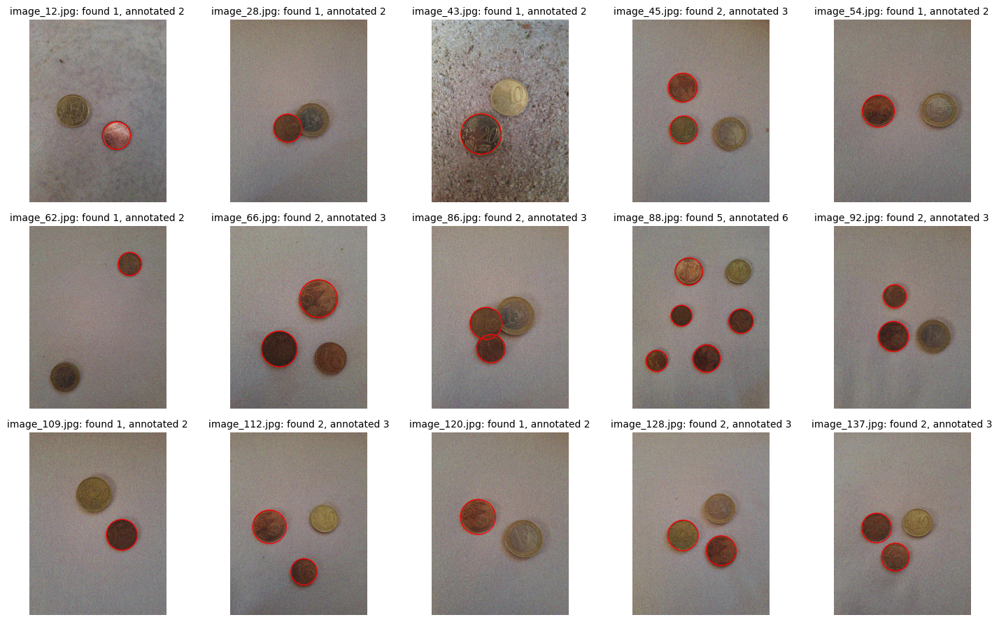

Subset,Images,Rows without notes,Exact composition,F1,MAE (€)
One predicted monometal coin (batch median scale),48,42,38.1%,40.4%,0.143
One predicted bimetal coin,11,11,100.0%,100.0%,0.000
Two or more detected coins,83,77,37.7%,69.5%,0.311


Of the 48 fallback images, 7 are annotated as containing multiple coins.
Fallback images also annotated as genuinely single: 16/37 primary rows have exact composition (43.2%).


In [ ]:
if ground_truth is not None:
    rows = []
    for filename in all_filenames:
        truth = ground_truth[filename]["count"]
        before = len(analysis_no_recovery[filename]["coins"])
        after = len(target_analysis[filename]["coins"])
        if before != truth or after != truth:
            rows.append({"Image": filename, "Annotated": truth, "Hough + validation": before,
                         "Second pass additions": target_analysis[filename]["recovered_candidates"], "Final": after})
    display(pd.DataFrame(rows).style.hide(axis="index"))
    print("Images with the correct count: "
          f"{sum(len(analysis_no_recovery[n]['coins']) == ground_truth[n]['count'] for n in all_filenames)} -> "
          f"{sum(len(target_analysis[n]['coins']) == ground_truth[n]['count'] for n in all_filenames)} of {len(all_filenames)} "
          "(before -> after the second pass)")

    deficits = [r["Image"] for r in rows if r["Final"] < r["Annotated"]]
    tiles = []
    for filename in deficits:
        image = correct_target_colour(load_image(target_analysis[filename]["path"]))
        for coin in target_analysis[filename]["coins"]:
            x, y, r = coin["circle"]
            cv2.circle(image, (x, y), r, (0, 255, 0) if coin["validation"]["source"] == "recovery" else (0, 0, 255), 3)
        tiles.append(image)
    show(tiles, [f"{n}: found {len(target_analysis[n]['coins'])}, annotated {ground_truth[n]['count']}" for n in deficits],
         ncols=5, figsize=3)

    subsets = [
        ("One predicted monometal coin (batch median scale)", [n for n in all_filenames if target_analysis[n]["scale_source"].startswith("single")]),
        ("One predicted bimetal coin", [n for n in all_filenames if len(target_analysis[n]["coins"]) == 1
                                 and not target_analysis[n]["scale_source"].startswith("single")]),
        ("Two or more detected coins", [n for n in all_filenames if len(target_analysis[n]["coins"]) >= 2]),
    ]
    rows = []
    for label, names in subsets:
        m = evaluate_predictions(target_analysis, names)
        rows.append({"Subset": label, "Images": m["images"], "Rows without notes": m["value_images"],
                     "Exact composition": m["composition_accuracy"], "F1": m["f1"], "MAE (€)": m["mae_eur"]})
    display(pd.DataFrame(rows).style.format({"Exact composition": "{:.1%}", "F1": "{:.1%}", "MAE (€)": "{:.3f}"}).hide(axis="index"))

    fallback_names = subsets[0][1]
    actually_single = [n for n in fallback_names if ground_truth[n]["count"] == 1]
    single_metrics = evaluate_predictions(target_analysis, actually_single)
    print(f"Of the {len(fallback_names)} fallback images, "
          f"{sum(ground_truth[n]['count'] > 1 for n in fallback_names)} are annotated as containing multiple coins.")
    print("Fallback images also annotated as genuinely single: "
          f"{round(single_metrics['composition_accuracy'] * single_metrics['value_images'])}/"
          f"{single_metrics['value_images']} primary rows have exact composition "
          f"({single_metrics['composition_accuracy']:.1%}).")

## 6. Discussion and limitations

*(Numbers refer to the saved run; Section 5 gives the metric definitions and scopes.)*

**Detection.** Hough + validation counts correctly 122 of 142 images. Validated recovery adds five circles and raises this to **127/142 (89.4 %)** without introducing new image-count discrepancies. Correct counts alone do not certify the absence of false detections. Fifteen net deficits remain; the grid often shows weak or partial boundaries, including light coins on grey floors and dark coins on dark backgrounds. Colour-contrast detection is a possible future experiment, not a demonstrated improvement.

**Material and the Otsu trade-off.** With recovery and geometry held fixed, replacing the reference copper/gold split with Otsu increases denomination-multiset F1 from **62.8 % to 66.2 %**. The broader **61.2 % → 66.2 %** change includes recovery as well. Exact composition stays at **43.1 %**; MAE improves slightly (**0.234 € → 0.230 €**), while RMSE worsens (**0.491 € → 0.511 €**) and primary total bias changes from **+0.73 € to −9.05 €**. We favoured denomination matching during development; Otsu does not dominate every metric. Its broad, overlapping colour distribution remains a limitation, and recovery with the reference split is a valid alternative when prioritising monetary RMSE.

**Scale and geometry.** A unique optimum in the discrete scale search is not proof of a correct physical scale. Among images with two or more detections, primary exact composition is only **29/77 (37.7 %)**, despite a higher multiset F1 of **69.5 %**. Material mistakes, perspective and displaced circles still affect size inference. Local refinement cannot correct large centre errors such as image 27; the ellipse comparison improves that example geometrically but lowers overall F1 under the tested configuration.

The **48 predicted-single monometal** images use a batch median of **7.519 px/mm**. The **14.7 % CV** describes variation across 80 model-derived multi-detection scale estimates, not uncertainty of the median itself; consecutive diameters within a material group differ by roughly 9–15 %. Within the 10th–90th percentile scale range, 39 of the 48 detections admit multiple denominations. Primary exact composition is **16/42 (38.1 %)**; restricting to fallback images annotated as genuinely single gives **16/37 (43.2 %)**. Seven fallback images actually contain multiple coins. SIFT accepts no target template under the tested thresholds (Appendix A); matching each reference to itself is only a sanity check. These results do not rule out other appearance methods or better reference coverage.

**Overall.** On the 130 primary rows, exact composition is **43.1 %**, denomination-multiset F1 **66.2 %**, MAE **0.230 €**, and the predicted amount **118.44 €** against **127.49 €** annotated. Over all 142 images the output is **313 coins and 124.94 €**. Better boundary evidence addresses missed detections; a known scale cue and richer reference images address denomination ambiguity. The notebook documents a reproducible traditional-CV experiment with measured limitations, rather than establishing robust recognition on new photographs.

## Appendix A. Alternatives that were tried and not adopted

Three alternatives were compared under the same evaluation scopes. None increased primary denomination-multiset F1 over the selected pipeline; some have lower monetary RMSE, as the table shows. These are development comparisons supporting a trade-off, not proof of universal superiority. This appendix also needs the annotation file.

* **A.1 Ellipse fitting on Canny contours.** Coins photographed obliquely are ellipses, and some Hough circles are visibly displaced (image 27, coin 1). Contours (Canny 30/70 after smoothing) with ≥ 80 points are fitted with `cv2.fitEllipse`; a fit replaces the circle if the median normalised residual is ≤ 0.04, it covers ≥ 70 % of the angles, its axis ratio is ≥ 0.55, its major semi-axis is within 0.65–1.35 of the Hough radius, its centre is within 0.7 r, and its boundary support/alignment are ≥ 0.60/0.80. A *gated* variant additionally requires a boundary-quality gain ≥ 0.05 over the circle. The ellipse improves the visible geometry in image 27 but, used for target colour regions and size over the whole set, lowers F1. This comparison retains circle-calibrated reference thresholds; it does not exhaust possible ellipse-based pipelines.
* **A.2 Colour prototype.** Instead of a single `G − B` threshold, each monometallic coin is assigned to the nearest reference coin in a three-part colour descriptor (hue, opponent chromaticity direction, Lab chroma direction). Worse than the thresholds.
* **A.3 Appearance matching (SIFT).** Each coin is resampled to a 201×201 patch; SIFT keypoints (CLAHE-enhanced, ratio test 0.7, unique train keypoints, similarity RANSAC with a 4 px threshold) are matched to the reference patches of the same material group; a match needs ≥ 8 inliers, ≥ 10 % hull coverage and a 1.5× lead over the runner-up. Applied to the single-coin images, it accepts no template.

In [ ]:
def ellipse_evidence(ellipse, edges, grad_x, grad_y, magnitude, band=3, num_samples=180):
    """Edge support and normal-gradient alignment along an ellipse (same idea as for circles)."""
    (x, y), (w, h), angle = ellipse
    t = np.linspace(0, 2 * np.pi, num_samples, endpoint=False)
    c, s = np.cos(t), np.sin(t)
    a, b = w / 2, h / 2
    ca, sa = np.cos(np.deg2rad(angle)), np.sin(np.deg2rad(angle))
    bx, by = x + ca * a * c - sa * b * s, y + sa * a * c + ca * b * s
    nx, ny = ca * c / a - sa * s / b, sa * c / a + ca * s / b
    norm = np.hypot(nx, ny)
    nx, ny = nx / norm, ny / norm
    offsets = np.arange(-band, band + 1)[:, None]
    xx = np.rint(bx + offsets * nx).astype(int)
    yy = np.rint(by + offsets * ny).astype(int)
    valid = (xx >= 0) & (yy >= 0) & (xx < edges.shape[1]) & (yy < edges.shape[0])
    xx, yy = np.clip(xx, 0, edges.shape[1] - 1), np.clip(yy, 0, edges.shape[0] - 1)
    support = float(np.mean(np.any((edges[yy, xx] > 0) & valid, axis=0)))
    sampled = np.where(valid, magnitude[yy, xx], -1)
    best = np.argmax(sampled, axis=0)
    columns = np.arange(num_samples)
    xx, yy = xx[best, columns], yy[best, columns]
    good = sampled[best, columns] >= 10
    alignment = np.abs(grad_x[yy, xx] * nx + grad_y[yy, xx] * ny) / (np.hypot(grad_x[yy, xx], grad_y[yy, xx]) + 1e-6)
    return support, float(np.mean(alignment[good])) if np.any(good) else 0.0


def fit_contour_ellipse(circle, contours, edges, grad_x, grad_y, magnitude):
    """Best ellipse among the contours compatible with a Hough circle, or None."""
    x, y, r = map(float, circle)
    choices = []
    for contour in contours:
        if len(contour) < 80:
            continue
        ellipse = cv2.fitEllipse(contour)
        (cx, cy), (w, h), angle = ellipse
        a, b = max(w, h) / 2, min(w, h) / 2
        if not (0.65 * r < a < 1.35 * r and b / a >= 0.55 and np.hypot(cx - x, cy - y) < 0.70 * r):
            continue
        points = contour[:, 0, :].astype(float) - [cx, cy]
        ca, sa = np.cos(np.deg2rad(angle)), np.sin(np.deg2rad(angle))
        u = (ca * points[:, 0] + sa * points[:, 1]) / (w / 2)
        v = (-sa * points[:, 0] + ca * points[:, 1]) / (h / 2)
        if np.median(np.abs(np.hypot(u, v) - 1)) > 0.04:
            continue
        bins = np.floor((np.arctan2(v, u) + np.pi) / (2 * np.pi) * 36).astype(int) % 36
        if len(np.unique(bins)) / 36 < 0.70:
            continue
        support, alignment = ellipse_evidence(ellipse, edges, grad_x, grad_y, magnitude)
        if support < 0.60 or alignment < 0.80:
            continue
        score = 0.6 * support + 0.4 * alignment - 0.03 * np.hypot(cx - x, cy - y) / r - 0.03 * abs(a - r) / r
        choices.append((score, ellipse, support, alignment))
    if not choices:
        return None
    _, ellipse, support, alignment = max(choices, key=lambda q: q[0])
    return ellipse, support, alignment


def normalized_patch(image, coin, half=100):
    """Resample the coin (circle or ellipse) to a (2*half+1)^2 patch: scale and tilt normalisation."""
    ellipse = coin.get("ellipse")
    if ellipse is None:
        x, y, r = coin["circle"]
        ellipse = ((x, y), (2 * r, 2 * r), 0.0)
    (x, y), (w, h), angle = ellipse
    v, u = np.mgrid[-half:half + 1, -half:half + 1].astype(np.float32) / half
    ca, sa = np.cos(np.deg2rad(angle)), np.sin(np.deg2rad(angle))
    map_x = (x + ca * w / 2 * u - sa * h / 2 * v).astype(np.float32)
    map_y = (y + sa * w / 2 * u + ca * h / 2 * v).astype(np.float32)
    return cv2.remap(image, map_x, map_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)


def analyse_ellipse_variant(results, gated=False):
    """Replace Hough circles by contour ellipses where a good fit exists; recompute colour and size."""
    variant = copy.deepcopy(results)
    accepted = 0
    for result in variant.values():
        raw = load_image(result["path"])
        gray = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)
        fine = cv2.GaussianBlur(gray, (9, 9), 2)
        edges = cv2.Canny(fine, 30, 70)
        contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
        grad_x, grad_y, magnitude = compute_gradient_maps(fine)
        colour_image = correct_target_colour(raw)
        for coin in result["coins"]:
            fit = fit_contour_ellipse(coin["hough_circle"], contours, edges, grad_x, grad_y, magnitude)
            if fit is None:
                continue
            ellipse, support, alignment = fit
            if gated:
                x, y, r = coin["circle"]
                circle_support, circle_alignment = ellipse_evidence(((float(x), float(y)), (2.0 * r, 2.0 * r), 0.0),
                                                                    edges, grad_x, grad_y, magnitude)
                if 0.6 * support + 0.4 * alignment - (0.6 * circle_support + 0.4 * circle_alignment) < 0.05:
                    continue
            (x, y), (w, h), _ = ellipse
            patch = normalized_patch(colour_image, {"ellipse": ellipse})
            features = compute_coin_colour_features(patch, 100, 100, 100)
            coin.update(ellipse=ellipse, circle=(x, y, max(w, h) / 2), size_radius=max(w, h) / 2, colour_features=features,
                        material_group=classify_material_group(features, alignment))
            accepted += 1
    return variant, accepted


def colour_vector(patch):
    """Hue, opponent-chromaticity direction and Lab chroma direction of the informative coin pixels."""
    v, u = np.mgrid[-100:101, -100:101]
    mask = (u * u + v * v) < 68 ** 2
    hsv = cv2.cvtColor(patch, cv2.COLOR_BGR2HSV)
    informative = mask & (hsv[:, :, 1] >= 30) & (hsv[:, :, 2] >= 40) & (hsv[:, :, 2] <= 245)
    if np.sum(informative) < 100:
        informative = mask
    hue = circular_median_hue(hsv[:, :, 0][informative])
    rgb = cv2.cvtColor(patch, cv2.COLOR_BGR2RGB).astype(float)
    chroma = np.median((rgb / (rgb.sum(axis=2, keepdims=True) + 1e-6))[informative], axis=0)
    opponent = np.array([chroma[0] - chroma[1], chroma[1] - chroma[2]])
    opponent /= np.linalg.norm(opponent) + 1e-6
    ab = np.median(cv2.cvtColor(patch, cv2.COLOR_BGR2LAB).astype(float)[informative, 1:], axis=0) - 128
    ab /= np.linalg.norm(ab) + 1e-6
    return np.r_[hue, opponent, ab]


def vector_distance(a, b):
    return (circular_hue_difference(a[0], b[0]) / 30) ** 2 + np.sum((a[1:3] - b[1:3]) ** 2) + np.sum((a[3:] - b[3:]) ** 2)


def sift_features(patch):
    gray = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY))
    v, u = np.mgrid[-100:101, -100:101]
    mask = np.uint8((u * u + v * v) < 90 ** 2) * 255
    return cv2.SIFT_create(contrastThreshold=0.03).detectAndCompute(gray, mask)


def match_sift(patch, names, reference_sift):
    """Best reference among `names`, or None if the match is not conclusive; plus all scores."""
    keypoints, descriptors = sift_features(patch)
    if descriptors is None:
        return None, []
    matcher = cv2.BFMatcher(cv2.NORM_L2)
    scores = []
    for name in names:
        ref_keypoints, ref_descriptors = reference_sift[name]
        pairs = matcher.knnMatch(descriptors, ref_descriptors, k=2) if ref_descriptors is not None else []
        good = [p[0] for p in pairs if len(p) == 2 and p[0].distance < 0.7 * p[1].distance]
        unique = {}
        for match in sorted(good, key=lambda m: m.distance):
            unique.setdefault(match.trainIdx, match)
        good = list(unique.values())
        if len(good) < 4:
            scores.append((0, 0.0, name))
            continue
        src = np.float32([keypoints[m.queryIdx].pt for m in good])
        dst = np.float32([ref_keypoints[m.trainIdx].pt for m in good])
        _, inliers = cv2.estimateAffinePartial2D(src, dst, method=cv2.RANSAC, ransacReprojThreshold=4,
                                                 maxIters=2000, confidence=0.99)
        if inliers is None:
            scores.append((0, 0.0, name))
            continue
        selected = src[inliers.ravel().astype(bool)]
        area = cv2.contourArea(cv2.convexHull(selected)) if len(selected) >= 3 else 0.0
        scores.append((len(selected), area / (np.pi * 90 ** 2), name))
    scores.sort(reverse=True)
    if len(scores) > 1 and scores[0][0] >= 8 and scores[0][1] >= 0.10 and scores[0][0] >= 1.5 * max(scores[1][0], 1):
        return scores[0][2], scores
    return None, scores

SIFT self-check on the reference patches: passed
Ellipse fits accepted: 143 (gated: 24); SIFT templates accepted on single-coin images: 0 (best inlier count over all single coins: 0)


Variant,Count acc.,Exact composition,Precision,Recall,F1,Exact value,MAE (€),RMSE (€),Total bias (€)
Final pipeline (second pass + Otsu),89.4%,43.1%,67.7%,64.8%,66.2%,43.1%,0.230,0.511,-9.05
"A.1 contour ellipses, reference split",89.4%,40.0%,62.2%,59.5%,60.8%,40.0%,0.237,0.482,+2.75
"A.1 gated ellipses, reference split",89.4%,42.3%,63.5%,60.8%,62.1%,42.3%,0.241,0.498,+1.77
"A.1 gated ellipses, Otsu split",89.4%,41.5%,67.0%,64.1%,65.5%,41.5%,0.237,0.517,-8.01
A.2 colour prototype,89.4%,35.4%,58.0%,55.5%,56.7%,35.4%,0.270,0.506,+8.10
A.3 final pipeline + SIFT on single coins,89.4%,43.1%,67.7%,64.8%,66.2%,43.1%,0.230,0.511,-9.05


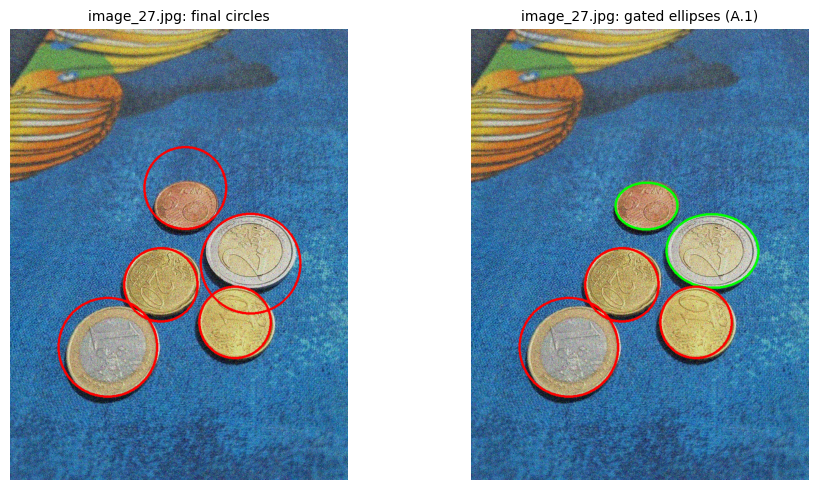

In [ ]:
if ground_truth is not None:
    # A.1 ellipses (plain and gated), each with the reference split and, for the gated one, also with Otsu.
    ellipse_analysis, ellipse_fits = analyse_ellipse_variant(analysis_reference_split)
    gated_analysis, gated_fits = analyse_ellipse_variant(analysis_reference_split, gated=True)
    gated_otsu_analysis = copy.deepcopy(gated_analysis)
    apply_monometal_threshold(gated_otsu_analysis, otsu_threshold_1d(
        [c["colour_features"]["inner_gb"] for r in gated_otsu_analysis.values() for c in r["coins"]
         if c["material_group"] in {"copper", "gold"}]))

    # A.2 colour prototype on the final detections.
    reference_patches = {n: normalized_patch(load_image(os.path.join(REFERENCE_DIR, n + ".jpg")), {"circle": reference_circles[n]})
                         for n in REFERENCE_VALUES}
    reference_vectors = {n: colour_vector(p) for n, p in reference_patches.items()}
    prototype_analysis = copy.deepcopy(analysis_reference_split)
    for result in prototype_analysis.values():
        image = correct_target_colour(load_image(result["path"]))
        for coin in result["coins"]:
            if coin["material_group"] in {"copper", "gold"}:
                vector = colour_vector(normalized_patch(image, coin))
                nearest = min(MONOMETAL_REFERENCE_NAMES, key=lambda n: vector_distance(vector, reference_vectors[n]))
                coin["material_group"] = "copper" if nearest in COPPER_REFERENCE_NAMES else "gold"

    # A.3 SIFT on the single-coin images of the final pipeline.
    reference_sift = {n: sift_features(p) for n, p in reference_patches.items()}
    self_check = all(match_sift(reference_patches[n], COPPER_REFERENCE_NAMES if n in COPPER_REFERENCE_NAMES
                                else GOLD_REFERENCE_NAMES, reference_sift)[0] == n for n in MONOMETAL_REFERENCE_NAMES)
    print("SIFT self-check on the reference patches:", "passed" if self_check else "FAILED")
    sift_analysis = copy.deepcopy(target_analysis)
    sift_accepted, best_inliers = 0, []
    for result in sift_analysis.values():
        if not result["scale_source"].startswith("single"):
            continue
        coin = result["coins"][0]
        names = COPPER_REFERENCE_NAMES if coin["material_group"] == "copper" else GOLD_REFERENCE_NAMES
        match, scores = match_sift(normalized_patch(correct_target_colour(load_image(result["path"])), coin), names, reference_sift)
        best_inliers.append(scores[0][0] if scores else 0)
        if match:
            sift_accepted += 1
            coin["predicted_value"] = REFERENCE_VALUES[match]
            result["partial_amount"] = coin["predicted_value"]

    print(f"Ellipse fits accepted: {ellipse_fits} (gated: {gated_fits}); SIFT templates accepted on single-coin images: "
          f"{sift_accepted} (best inlier count over all single coins: {max(best_inliers) if best_inliers else 0})")
    rows = [
        metrics_row("Final pipeline (second pass + Otsu)", primary),
        metrics_row("A.1 contour ellipses, reference split", finish_and_evaluate(ellipse_analysis)),
        metrics_row("A.1 gated ellipses, reference split", finish_and_evaluate(gated_analysis)),
        metrics_row("A.1 gated ellipses, Otsu split", finish_and_evaluate(gated_otsu_analysis)),
        metrics_row("A.2 colour prototype", finish_and_evaluate(prototype_analysis)),
        metrics_row("A.3 final pipeline + SIFT on single coins", evaluate_predictions(sift_analysis, all_filenames)),
    ]
    display(pd.DataFrame(rows).style.format(METRIC_FORMAT).hide(axis="index"))

    # Image 27: the ellipse corrects the displaced circle, which is why A.1 was worth trying.
    tiles = []
    for results in (target_analysis, gated_analysis):
        result = results["image_27.jpg"]
        image = correct_target_colour(load_image(result["path"]))
        for coin in result["coins"]:
            if "ellipse" in coin:
                cv2.ellipse(image, coin["ellipse"], (0, 255, 0), 3)
            else:
                x, y, r = map(int, coin["circle"])
                cv2.circle(image, (x, y), r, (0, 0, 255), 3)
        tiles.append(image)
    show(tiles, ["image_27.jpg: final circles", "image_27.jpg: gated ellipses (A.1)"], figsize=5)